# RESCUE Jumper: Jumping Model


This notebook contains the jumping model described in the paper titled: RESCUE Jumper: A Centimeter-Scale Rolling and Jumping Robot for Search and Rescue. The code develops each phase of the model discussed in Section III. Jumping Model and analyzes experimental data discussed in Section IV. Experiments. The code was originally developed in Google Colab.

The sections are:
1. Setup
2. Experimental data analysis
3. Phase 1: Contact point and orientation after tail release
4. Phase 2: Tail extension until litfoff
5. Phase 3: Ballistic trajectory
6. Complete model pipeline

# Setup




### Imports and global settings

In [1]:
import numpy as np
import pandas as pd
import csv
import math

from ipywidgets import interact, IntSlider, Layout
from IPython.display import display

from scipy.optimize import brentq
from scipy.integrate import solve_bvp, solve_ivp

import matplotlib.pyplot as plt
from matplotlib.patches import Arc
import matplotlib.ticker as mticker
from matplotlib.lines import Line2D

from dataclasses import dataclass, astuple, replace

datapath = './Data'

plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif']  = ['Times New Roman']
plt.rcParams['font.size']       = 10
plt.rcParams['axes.titlesize']  = 10
plt.rcParams['axes.labelsize']  = 10
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10
plt.rcParams['legend.fontsize'] = 10

### General helper functions

In [2]:
# Rotation matrix of angle
def rot(ang):
  return np.array([[np.cos(ang), -np.sin(ang)],
                    [np.sin(ang),  np.cos(ang)]])

# Wrap angle from -pi to pi
def wrap(ang):
    if ang > np.pi: return ang - 2*np.pi
    elif ang <= -np.pi: return ang + 2*np.pi
    else: return ang

# Wrap vector of angles from 0 to 2pi
def wrap_02pi(v):
    return np.asarray(v, dtype=float) % (2*np.pi)

# Return the argsort order and viridis colors for later plots
def sort_by_omega(omega_vals):
    order = np.argsort(omega_vals)
    exp_colors   = plt.cm.viridis(np.linspace(0, 1, len(percentages)))
    model_colors = exp_colors[order]
    return order, exp_colors, model_colors

# Build shared model + per-speed legend once
def legend_handles_labels(exp_colors):
    model_handle = Line2D([0], [0], color='gray', linestyle='-', marker='o',
                          markersize=2.5, markerfacecolor='gray',
                          markeredgecolor='k', markeredgewidth=0.3)
    exp_handles = [Line2D([0], [0], color=c, linestyle='None', marker='s',
                          markersize=2.5) for c in exp_colors]
    labels = ['model'] + [f'{dataframes[p]["wind_omega_rad_s"].mean():.2f} rad/s'
                          for p in percentages]
    return [model_handle] + exp_handles, labels

# Plot model-vs-experiment panel with optional angle wrap
def plot_panel(ax, omega_sorted, model_sorted, exp_col, ylabel,
               exp_colors, model_colors, scale=1.0, wrap_ang=False):
    w = wrap_02pi if wrap_ang else (lambda v: v)

    ax.plot(omega_sorted, w(model_sorted)*scale, '-', color='gray', zorder=2,
            marker='o', markersize=2.5, markerfacecolor='gray',
            markeredgecolor='k', markeredgewidth=0.3, label='model')
    ax.scatter(omega_sorted, w(model_sorted)*scale, color=model_colors,
               s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
    for pct, c in zip(percentages, exp_colors):
        df_pct = dataframes[pct]
        ax.scatter(df_pct['wind_omega_rad_s'], w(df_pct[exp_col])*scale,
                   color='lightgray', s=5, zorder=1)
        om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
        v_m,  v_s  = w(df_pct[exp_col]).mean()*scale, w(df_pct[exp_col]).std()*scale
        ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                    fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                    zorder=4, label=f'{om_m:.2f} rad/s')
    ax.set_ylabel(ylabel)
    ax.grid(True)

### Parameters

In [3]:
g = 9.81;               # Acceleration due to gravity [m/s^2]

# Tail parameters
E = 200e9               # Spring steel elastic modulus [Pa]
L = 0.100               # Tail length [m]
L_test = 0.095          # Test tail length [m]: model system ID sensitivity
w = 23.5e-3             # Tail width [m]
d = 0.2032e-3           # Tail thickness [m]
I_tail = w * d**3 / 12  # Tail area moment of inertia [m^4]
m_tail = 0.007          # Tail mass [kg]
lam = m_tail/L          # Tail linear density [kg/m]
N = 200;                # Number of tail nodes for elastica solver

# Robot parameters
m_bot = 0.125 - m_tail;               # Robot mass [kg]
speed_nom = 26700/64 * (2*np.pi)/60   # Motor nominal speed [rad/s]
                                      # = [RPM] / gearbox * [rad/rev * min/s]
r_body = 0.028;        # Inner body radius [m]
r_wheel = 0.031;       # Wheel radius [m]
I_CM = 33921.50*1e-9;  # Mass moment of inertia about CG [kg m^2] (no tail)
I_CR = 37124.39*1e-9;  # Mass moment of inertia about CR [kg m^2] (tail wrapped)

d_gap = 0.8e-3                # Gap from rod to inner body [m]
r_wrap = r_body + d_gap - d   # Effective wrapping radius [m]

p_anchor = np.array([[0], [-r_body]])       # Initial anchor position [m]
p_CG = np.array([[0.34], [1.96]])/1000      # Initial CG position [m] (tail wrapped)
p_CG_test = np.array([[0.72], [1.85]])/1000 # Test initial CG position [m]: model system ID sensitivity
p_rod = np.array([[0], [-r_wrap]])          # Initial rod position [m]
r_CG = np.linalg.norm(p_CG)                 # Radius of CG from CR [m]
phi_rod = np.acos(1 - (d_gap - d)/r_wrap)   # Rod offset before winding [rad]
p_rod_offset = rot(phi_rod) @ p_rod         # Rod position at phi_rod [m]
L_const = p_rod_offset[0,0]                 # Constant length tail section [m]

# Experimental data analysis

### Load Data

In [4]:
# Winding speeds were originally commanded as percentages of nominal speed
# to a PID controller tuned during forward motion. The data files reflect
# this percentage in their naming convention.

percentages = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100]
dataframes = {}

for pct in percentages:
    results = []

    for trial_num in range(1,7): # N = 6 trials per windup speed
        filename = f'{datapath}/trial{trial_num}_{pct}p.xlsx'

        # Import and skip to the header row (row 3, 0-indexed = 2)
        df = pd.read_excel(filename, header=2)

        # Rename columns: t, x, y, vx, vy, v, thetav are repeated for each point mass (not all used)
        # Point A tracks the CR
        # Point B tracks the rods
        # Point C tracks the the tail end
        # Point D tracks the anchor flag
        cols = list(df.columns)
        cols[0]  = 't'
        cols[1],  cols[2],  cols[3],  cols[4],  cols[5],  cols[6]  = 'x_A',  'y_A',  'vx_A',  'vy_A',  'v_A',  'thetav_A'
        cols[7],  cols[8],  cols[9],  cols[10], cols[11], cols[12] = 'x_B',  'y_B',  'vx_B',  'vy_B',  'v_B',  'thetav_B'
        cols[13], cols[14], cols[15], cols[16], cols[17], cols[18] = 'x_C',  'y_C',  'vx_C',  'vy_C',  'v_C',  'thetav_C'
        cols[19], cols[20], cols[21], cols[22], cols[23], cols[24] = 'x_D',  'y_D',  'vx_D',  'vy_D',  'v_D',  'thetav_D'
        df.columns = cols

        # Convert thetav from degrees to radians
        # This is the direction of CR motion used to get liftoff direction
        df['thetav_A'] = np.radians(df['thetav_A'])

        # omega from mass C: vx_avg / r_body
        first_nan = df['x_C'].isna().idxmax() if df['x_C'].isna().any() else None
        x_C_valid = df['x_C'].loc[:first_nan].iloc[:-1] if first_nan is not None else df['x_C']
        t_valid   = df['t'][x_C_valid.index]
        wind_omega = (x_C_valid.iloc[-1] - x_C_valid.iloc[0]) / (t_valid.iloc[-1] - t_valid.iloc[0]) / r_body

        # Max height of CR y_peak
        idx_y = df['y_A'].idxmax()
        row_y = df.loc[idx_y]

        # Mark contact point when tail end is visible after release and before liftoff
        # Determine contact point in relation to first frame where vy_A exceeds 0.1 m/s
        idx_ct = df[df['vy_A'] > 0.1].index[0]
        row_ct = df.loc[idx_ct]
        x_ct = row_ct['x_A']
        y_ct = row_ct['y_A']
        idx_ctval = df['x_C'].last_valid_index()
        x_C = df['x_C'].loc[idx_ctval]
        y_C = df['y_C'].loc[idx_ctval]
        contact_x = x_C - x_ct
        contact_y = y_C - y_ct

        # Landing determined as the first time |a_y| exceeds 100 m/s^2
        # Uses Tracker's finite difference formula:
        # https://opensourcephysics.github.io/tracker-website/help/frameset.html
        dt = np.median(np.diff(df['t']))
        y = df['y_A'].to_numpy()
        a_y = np.full(len(y), np.nan)
        a_y[2:-2] = (2*y[4:] - y[3:-1] - 2*y[2:-2] - y[1:-3] + 2*y[:-4]) / (7*dt**2)
        mask = np.abs(a_y) > 100
        idx_end = np.argmax(mask) if mask.any() else None
        t_end = df['t'].iloc[idx_end]
        x_end = df['x_A'].iloc[idx_end]

        # Angular velocity of inner body, angular velocity of wheel w.r.t. inner body
        def omega_about_A(mass):
            dx = df[f'x_{mass}'] - df['x_A']
            dy = df[f'y_{mass}'] - df['y_A']
            ang = np.unwrap(np.arctan2(dy, dx))
            t   = df['t'].to_numpy()

            return (ang[idx_end] - ang[idx_ct]) / (t[idx_end] - t[idx_ct]) # average

        omega_body = omega_about_A('D')
        omega_wheel  = omega_about_A('B') - omega_body

        # Orientation at contact
        offset = 50 * (np.pi/180) # Anchor is offset 50 deg CCW from flag
        flag_from_pos_x = np.arctan2(df['y_D'] - df['y_A'], df['x_D'] - df['x_A'])
        flag_from_neg_y = flag_from_pos_x + np.pi/2 # -pi < first term < 0
        anchor_theta = np.unwrap(flag_from_neg_y) + offset
        phi_contact = anchor_theta[idx_ct] % (2*np.pi)  # all in [0, 2*pi)
        if phi_contact < 0:
            phi_contact += 2*np.pi # -> (-2*pi, 0], negative

        # Determine liftoff state when anchor to contact_point exceeds tail length L
        dx = df['x_B'] - df['x_A']
        dy = df['y_B'] - df['y_A']
        cos_o, sin_o = np.cos(offset), np.sin(offset)
        x_anchor_true = df['x_A'] + (dx*cos_o - dy*sin_o)
        y_anchor_true = df['y_A'] + (dx*sin_o + dy*cos_o)
        chords = np.sqrt((x_anchor_true - x_C)**2 + (y_anchor_true - y_C)**2)
        idx_vy = df.index[chords >= L][0]
        row_vy = df.loc[idx_vy]

        # Orientation at liftoff - use anchor angle sampled at the liftoff frame
        phi_liftoff = anchor_theta[idx_vy] % (2*np.pi)
        if phi_liftoff < 0:
            phi_liftoff += 2*np.pi

        # Angular velocity at liftoff is the local slope of the CR to anchor angle
        t_arr = df['t'].to_numpy()
        nd = 5
        omega_liftoff = (anchor_theta[idx_vy + nd] - anchor_theta[idx_vy - nd]) / \
                        (t_arr[idx_vy + nd] - t_arr[idx_vy - nd])

        # Gather results
        results.append({
            'trial':                trial_num,
            'wind_omega_rad_s':     np.abs(wind_omega), # np.abs(omega / (2*np.pi/60))
            'contact_x':            contact_x,
            'phi_contact':          phi_contact,
            'omega_body_rad_s':     omega_body,
            'omega_wheel_rad_s':    omega_wheel,
            't_liftoff':            row_vy['t'],
            'x_liftoff':            row_vy['x_A'],
            'y_liftoff':            row_vy['y_A'],
            'vx_liftoff':           row_vy['vx_A'],
            'vy_liftoff':           row_vy['vy_A'],
            'v_liftoff':            row_vy['v_A'],
            'theta_liftoff':        row_vy['thetav_A'],
            'phi_liftoff':          phi_liftoff,
            'omega_liftoff':        omega_liftoff,
            't_peak':               row_y['t'],
            'y_peak':               row_y['y_A'],
            't_end':                t_end,
            'x_end':                x_end,
        })

    # Access individual dataframes via dataframe[pct]
    dataframes[pct] = pd.DataFrame(results)

    commanded_speed = pct/100 * speed_nom;
    print(f"\n--- {pct}% ({commanded_speed:.3f} rad/s)---")
    print(dataframes[pct].to_string())


--- 10% (4.369 rad/s)---
   trial  wind_omega_rad_s  contact_x  phi_contact  omega_body_rad_s  omega_wheel_rad_s  t_liftoff  x_liftoff  y_liftoff  vx_liftoff  vy_liftoff  v_liftoff  theta_liftoff  phi_liftoff  omega_liftoff  t_peak   y_peak  t_end    x_end
0      1          0.810209   0.011131     3.605327         21.475000          32.316076      3.799   -0.05338    0.06486      -0.538       0.409      0.676       2.492330     5.736819      18.203940   3.831  0.07149  3.967 -0.12600
1      2          0.731385   0.007197     3.429294         21.604715          30.621156      3.921   -0.02350    0.07443      -0.301       0.645      0.712       2.007129     5.492808      18.594378   3.968  0.08873  4.115 -0.05938
2      3          0.701307   0.009405     3.387643         22.219833          29.291902      3.931   -0.02460    0.07252      -0.221       0.611      0.650       1.918117     5.468749      19.037420   3.983  0.08740  4.126 -0.06651
3      4          0.736217   0.010709     3.60

### Results summary

In [5]:
print("----------------------------\nExperimental results stats:\n----------------------------\n")
stats_rows = []
stats_cols = ['wind_omega_rad_s', 'contact_x', 'phi_contact', 'v_liftoff', 'theta_liftoff', 'phi_liftoff', 'omega_liftoff', 'y_peak']

for pct in percentages:
    df_pct = dataframes[pct]

    row = {'pct': pct, 'N': len(df_pct)}
    for col in stats_cols:
        row[col]            = df_pct[col].mean()
        row[f'{col}_std']   = df_pct[col].std()
    stats_rows.append(row)

df_stats = pd.DataFrame(stats_rows).set_index('pct')
print(df_stats.to_string())
print("\n")

# Format results to more easily visually compare 1 to 1 compare with model
print("----------------------------\nExperimental results:\n----------------------------\n")
summary_rows = []
summary_cols = ['wind_omega_rad_s', 'contact_x', 'phi_contact',
                'x_liftoff', 'y_liftoff', 'vx_liftoff', 'vy_liftoff',
                'v_liftoff', 'theta_liftoff', 'phi_liftoff',
                'omega_liftoff', 'y_peak', 'x_end']
for pct in percentages:
    df_pct = dataframes[pct]

    row = {'pct': pct}
    for col in summary_cols:
        row[col] = df_pct[col].mean()
    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows).set_index('pct')

# Phrase as degrees from vertical axis
df_summary['theta_liftoff_deg'] = np.degrees(df_summary['theta_liftoff']) - 90

print(df_summary.to_string())
print("\n")

----------------------------
Experimental results stats:
----------------------------

     N  wind_omega_rad_s  wind_omega_rad_s_std  contact_x  contact_x_std  phi_contact  phi_contact_std  v_liftoff  v_liftoff_std  theta_liftoff  theta_liftoff_std  phi_liftoff  phi_liftoff_std  omega_liftoff  omega_liftoff_std    y_peak  y_peak_std
pct                                                                                                                                                                                                                                                     
10   6          0.750304              0.039174   0.012086       0.004313     3.583632         0.166382   0.693333       0.026212       2.369866           0.351014     5.671701         0.176293      19.336861           1.171582  0.072283    0.015445
20   6          1.436286              0.032827   0.010568       0.001298     3.456271         0.062227   0.669500       0.034715       2.145591           0.143047    

# Phase 1: Contact point and orientation after tail release

### Energy method evaluation using Equation 14

In [6]:
kappa_w = 1/r_body                    # Constant curvature of wrapped tail section [1/m]
M_w = E*I_tail*kappa_w                # Constant internal bending moment [N m]
U_w = 0.5*M_w*kappa_w*L               # Potential energy of wrapped portion [J]
v_free = np.sqrt(3/7*M_w*kappa_w/lam) # Linear velocity of free tail section [m/s]
theta_w = L/r_body                    # Wrapped angle of tail around body [rad]
t_unwind = r_body*theta_w**2/(4*v_free)      # Time to go from wound to flat [s]
print(f"Time to completely unwind: {t_unwind:.4f} s")

# Retrieved from video of tail unwinding from fully wound
t_video = 0.0160
error_unwind = np.abs(t_video - t_unwind)/t_video * 100
print(f"Error: {error_unwind:.1f} %")

Time to completely unwind: 0.0176 s
Error: 10.2 %


### Plotting function

In [7]:
# Snapshot structure for plotting windup and release
@dataclass
class WindupSnapshot:
    p_tail: np.ndarray
    phi: np.ndarray
    p_CG: np.ndarray
    p_anchor: np.ndarray
    p_peel: np.ndarray
    p_rod_offset: np.ndarray
    t_sim: float

# Plot phase 1 at a given snapshot of the robot during winding
def plot_phase_1(snapshot, title, fig, ax):
    # Get windup info from snapshot
    p_tail, phi, p_CG, p_anchor, p_peel, p_rod_offset, t_sim = astuple(snapshot)

    # Ground line
    ax.axhline(-r_wheel, color='r', linestyle='-')

    # Robot body circle
    phi = np.linspace(0, 2*np.pi, 200)
    ax.plot(r_body*np.cos(phi), r_body*np.sin(phi), 'k-', lw=2)

    # Wheel dotted circle
    ax.plot(r_wheel*np.cos(phi), r_wheel*np.sin(phi), 'k:', lw=1.5)

    # Wrapped tail arc along r_body from anchor to vertical or peel (CCW)
    theta_A = np.arctan2(p_anchor[1,0], p_anchor[0,0])
    theta_P = np.arctan2(p_peel[1,0], p_peel[0,0])
    if theta_A < 0: theta_A += 2*np.pi
    if theta_P < 0: theta_P += 2*np.pi
    arc_angles = np.linspace(theta_P, theta_A, 100)
    ax.plot(r_body*np.cos(arc_angles), r_body*np.sin(arc_angles), 'b-', lw=3)

    # Free tail: straight line from peel to tail end
    ax.plot([p_peel[0,0], p_tail[0,0]], [p_peel[1,0], p_tail[1,0]], 'b-', lw=3)

    # Peel point, rod point, anchor point, tail end, CR, CG
    ax.plot(p_peel[0,0], p_peel[1,0], 'bo', ms=8)
    ax.plot(p_rod_offset[0,0], p_rod_offset[1,0], 'ro', ms=8)
    ax.plot(p_anchor[0,0], p_anchor[1,0], 'ks', ms=8)
    ax.plot(p_tail[0,0], p_tail[1,0], 'ko', ms=8)
    ax.plot(0, 0, 'ko', ms=8)
    ax.plot(p_CG[0,0], p_CG[1,0], 'b^', ms=8)

    # Total tail length: wrapped arc + free straight segment
    L_wrapped_plot = r_body * (theta_P - theta_A)
    L_free_plot = np.linalg.norm(p_tail - p_peel)
    L_total_plot = L_wrapped_plot + L_free_plot

    ax.set_aspect('equal')
    ax.grid(True)
    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    if title:
        ax.set_title(f"{title}\nL_total = {L_total_plot:.3f} m")

### Calculate contact point and orientation from windup speed at any time t

In [8]:
# Initial winding configuration
reference_snapshot = WindupSnapshot(
  p_tail = p_anchor + np.array([[L], [0]]),
  phi = 0,
  p_CG = p_CG,
  p_anchor = p_anchor,
  p_peel = p_anchor,
  p_rod_offset = p_rod,
  t_sim = 0
)

# Calculate tail position from windup speed
def tail_pos(omega, t, sol):

  #----- CG not yet crossed vertical
  phi = -omega*t  # current CW displacement of A
  phi_CG_cross = np.arctan2(p_CG[1,0], p_CG[0,0]) + np.pi/2
                  # CW displacement from initial p_CG to the vertical

  # If the CG has not yet crossed the negative vertical:
  if np.abs(phi) <= phi_CG_cross:
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor

    L_wrapped = np.abs(phi*r_body)
    L_rem = L - L_wrapped - L_const
    L_vec = (p_rod_offset - p_anchor) / np.linalg.norm(p_rod_offset - p_anchor)
    p_tail_new = L_rem * L_vec + p_rod_offset

    p_peel = p_anchor # default location, not yet peeling
    return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod_offset]

  #----- CG crossed vertical - causes interaction between CG moment and winding
  t_end = t - phi_CG_cross/omega  # step relative to the crossing time

  theta_outer_t = sol.y[0]; theta_inner_t = sol.y[2]; times = sol.t
  phi_t = -phi_CG_cross + (theta_outer_t + theta_inner_t) # current CW displacement of A
  t_end_idx = np.argmin(np.abs(times - t_end))            # index of time t_end

  # Check if tail yet to release
  phi = phi_t[t_end_idx]      # negative
  theta_outer = theta_outer_t[t_end_idx]  # positive
  L_wrapped = np.abs((phi + -theta_outer) * r_body) # Negative addition for CW
  L_rem = L - L_wrapped - L_const

  # Didn't release yet, return state
  if L_rem > 0.0005: # tolerance
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor
    p_rod2 = rot(theta_outer) @ p_rod_offset

    # Sign check: outer is positive, rod goes CCW
    p_peel = rot(theta_outer) @ p_anchor
    L_vec = (p_rod2 - p_peel) / np.linalg.norm(p_rod2 - p_peel)
    p_tail_new = L_rem * L_vec + p_rod2

    return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod2]

  #----- Tail must've released if L_rem <= tol - find where
  for phi, theta_outer, ti in zip(phi_t[:t_end_idx], theta_outer_t[:t_end_idx], times[:t_end_idx]):
    p_CG2 = rot(phi) @ p_CG
    p_anchor2 = rot(phi) @ p_anchor
    p_rod2 = rot(theta_outer) @ p_rod_offset

    L_wrapped = np.abs((phi + -theta_outer) * r_body)
    L_rem = L - L_wrapped - L_const

    # Sign check: outer is positive, rod goes CCW
    p_peel = rot(theta_outer) @ p_anchor
    L_vec = (p_rod2 - p_peel) / np.linalg.norm(p_rod2 - p_peel)
    p_tail_new = L_rem * L_vec + p_rod2

    # Find tail release, keep most recent loop values at release
    if L_rem <= 0.0005:
      break

  # Tail extends quickly, so we fix state at release
  t_rem = t_end - ti    # Time from tail release to time of interest

  # Peel point in body frame rotates CW from the fixed bottom reference
  delta_theta_peel = 2*np.sqrt(v_free/r_body*t_rem)
  p_peel = rot(-delta_theta_peel) @ rot(theta_outer) @ (rot(phi_rod) @ p_anchor)

  # Tail end found tangent at peel point along straight free portion
  tangent = rot(np.pi/2) @ p_peel / np.linalg.norm(p_peel)
  L_free = r_body*delta_theta_peel
  p_tail_new = p_peel + (L_free + L_rem)*tangent

  return [p_tail_new, phi, p_CG2, p_anchor2, p_peel, p_rod2]

# Step to find time at which tail position contacts ground
def omega_to_contact_pt(omega):
  windup_snapshots = [reference_snapshot]
  t_sim = 0
  dt = 1e-4   # simulation timestep
  t_max = 5   # longer than this indicates an error

  # Presolve interaction between theta_inner and theta_outer
  def dynamics(t, angles):
    theta_outer, theta_outer_dot, theta_inner = angles
    theta_from_vertical = theta_outer + theta_inner # math reference +

    tau = m_bot*g * r_CG*np.sin(-theta_from_vertical) # should be CCW +
    theta_outer_ddot = tau / I_CR
    theta_inner_dot = -omega

    return [theta_outer_dot, theta_outer_ddot, theta_inner_dot]

  angles0 = [0, 0, 0] # starting from when CG crosses vertical
  sol = solve_ivp(dynamics, [0, t_max], angles0, max_step=dt)

  # Get contact point
  while t_sim < t_max:
    t_sim += dt
    p_tail, phi, p_CG, p_anchor, p_peel, p_rod_offset = tail_pos(omega, t_sim, sol)
    p_tail_y = p_tail[1]

    # Store snapshots for plotting
    snapshot = WindupSnapshot(
      p_tail = p_tail.copy(),
      phi = phi,
      p_CG = p_CG.copy(),
      p_anchor = p_anchor.copy(),
      p_peel = p_peel.copy(),
      p_rod_offset = p_rod_offset.copy(),
      t_sim = t_sim
    )
    windup_snapshots.append(snapshot)

    # Condition for tail end reaching the ground
    if p_tail_y <= -r_wheel:
      break

  return windup_snapshots

### Plot pre-wind to contact for example windup speed

Tail end at contact: [0.0057, -0.0316]
Anchor rotation at contact: -3.339 rad
Time to contact ground: 0.38370 s


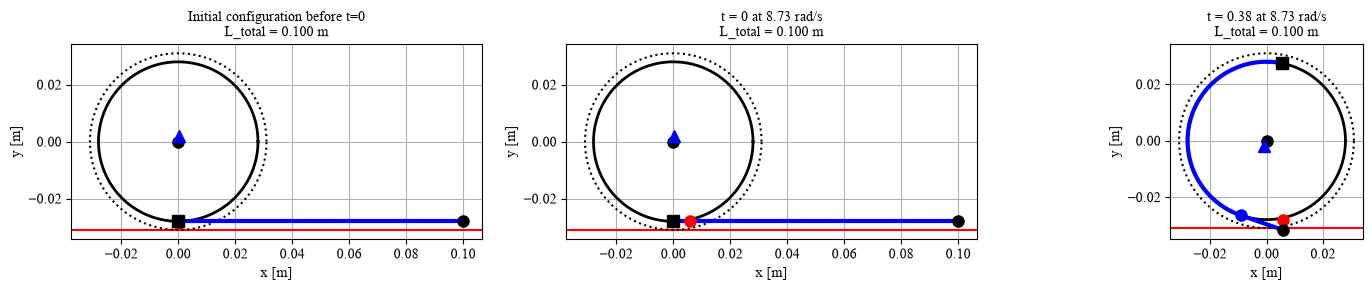

In [9]:
# Visualize at example windup speed
omega_wind_eg = 8.73
snapshots_eg = omega_to_contact_pt(omega_wind_eg)
p_tail_eg, phi_eg, p_CG_eg, p_anchor_eg, p_peel_eg, p_rod_offset_eg, t_eg = astuple(snapshots_eg[-1])

print(f"Tail end at contact: [{p_tail_eg[0,0]:.4f}, {p_tail_eg[1,0]:.4f}]")
print(f"Anchor rotation at contact: {phi_eg:.3f} rad")
print(f"Time to contact ground: {t_eg:.5f} s")

fig, axs = plt.subplots(1, 3, figsize = (15, 3))
plot_phase_1(snapshots_eg[0], "Initial configuration before t=0", fig, axs[0])
plot_phase_1(snapshots_eg[1], f"t = 0 at {omega_wind_eg} rad/s", fig, axs[1])
plot_phase_1(snapshots_eg[-1], f"t = {t_eg:.2f} at {omega_wind_eg} rad/s", fig, axs[2])
plt.tight_layout()
plt.show()

### Visualize interactive evolution for example windup speed

In [10]:
numsteps = len(snapshots_eg)
print(f"Number of steps: {numsteps}")

def show_frame(i):
    fig, ax = plt.subplots(figsize=(8, 8))
    plot_phase_1(snapshots_eg[i], f"t = {snapshots_eg[i].t_sim:.5f} at {omega_wind_eg} rad/s", fig, ax)
    ax.set_xlim([-0.05, 0.125])
    ax.set_ylim([-0.04, 0.04])
    plt.tight_layout()
    plt.show()

interact(show_frame,
         i=IntSlider(min=0, max=numsteps-1, step=1, value=0,
                     description='step', continuous_update=True,
                     layout=Layout(width='800px')))


Number of steps: 3838


interactive(children=(IntSlider(value=0, description='step', layout=Layout(width='800px'), max=3837), Output()…

<function __main__.show_frame(i)>

### Simulate at every windup speed

In [11]:
omega_wind_exp_vals = df_summary['wind_omega_rad_s']
contact_snapshots = []
count = 0

for omega_wind_exp in omega_wind_exp_vals:
  contact_snapshot = omega_to_contact_pt(omega_wind_exp)[-1]
  contact_snapshots.append(contact_snapshot)
  count = count + 1
  print(f"Finished running {count}/{len(omega_wind_exp_vals)}")

Finished running 1/10
Finished running 2/10
Finished running 3/10
Finished running 4/10
Finished running 5/10
Finished running 6/10
Finished running 7/10
Finished running 8/10
Finished running 9/10
Finished running 10/10


### Phase 1 output plot: Model vs Results

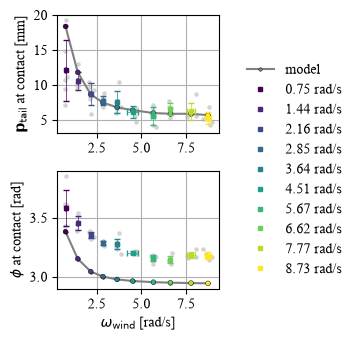

In [12]:
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))

# Phase 1 model
commanded_pct = df_summary.index
contact_x_vals = [cs.p_tail[0,0] for cs in contact_snapshots]
phi_vals = [cs.phi + 2*np.pi if cs.phi < 0 else cs.phi for cs in contact_snapshots]

# Sort by omega so connecting lines read left-to-right
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_wind_exp_vals_sorted = np.array(omega_wind_exp_vals)[order]
contact_x_vals_sorted = np.array(contact_x_vals)[order]
phi_vals_sorted = np.array(phi_vals)[order]
pct_sorted = np.array(commanded_pct)[order]

# Plot predicted + experimental contact x distance per windup speed
plot_panel(axs[0], omega_wind_exp_vals_sorted, contact_x_vals_sorted, 'contact_x',
           r'$\mathbf{p}_\mathrm{tail}$ at contact [mm]',
           exp_colors, model_colors, scale=1000)

# Plot predicted + experimental orientation at contact per windup speed
plot_panel(axs[1], omega_wind_exp_vals_sorted, phi_vals_sorted, 'phi_contact',
           r'$\phi$ at contact [rad]',
           exp_colors, model_colors, wrap_ang=True)

axs[1].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# Single shared legend beside subplots
handles, labels = legend_handles_labels(exp_colors)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           ncol=1, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

### Phase 1 RMSE

In [13]:
RMSE_P1_contact_x = np.sqrt(np.mean((contact_x_vals_sorted-df_summary['contact_x'])**2))
RMSE_P1_phi = np.sqrt(np.mean((phi_vals_sorted-df_summary['phi_contact'])**2))

print(f"Phase 1 RMSE contact: {RMSE_P1_contact_x*1000:.1f} mm")
print(f"Phase 1 RMSE phi: {np.degrees(RMSE_P1_phi):.1f} degrees")

Phase 1 RMSE contact: 2.1 mm
Phase 1 RMSE phi: 14.6 degrees


# Phase 2: Tail extension until liftoff

### Dataclasses

In [14]:
# Snapshot structure for plotting tail
@dataclass
class TailSnapshot:
    x_all: np.ndarray
    y_all: np.ndarray
    theta_all: np.ndarray
    omega_all: np.ndarray
    M_all: np.ndarray
    Px_all: np.ndarray
    Py_all: np.ndarray
    A: np.ndarray
    O: np.ndarray
    t_sim: float

# Snapshot structure for plotting robot
@dataclass
class RobotSnapshot:
    state_CR: np.ndarray
    state_anchor: np.ndarray
    state_CG: np.ndarray
    F_anchor: np.ndarray
    F_weight: np.ndarray
    M_applied: np.ndarray
    t_sim: float

### Plotting functions

In [15]:
fs = 0.009    # force arrow scale factor
max_r = 0.01  # radius of moment arrow [m]
max_M = 0.1   # max moment to scale arrow to [N m]

# Arrow plotting function
def arrow(ax, h, v, dh, dv, color):
  ax.annotate('', xy=(h + fs*dh, v + fs*dv), xytext=(h, v),
                  arrowprops=dict(arrowstyle='->', color=color, lw=2))

# Plotting function for tail
def plot_solution(snapshot, title, fig, ax, timoshenko_axes=False, force_arrows=True):
    x_all, y_all, theta_all, omega_all, M_all, Px_all, Py_all, A, O, t_sim = astuple(snapshot)
    M = M_all[-1]
    Px = Px_all[0]
    Py = Py_all[0]

    # Flip data to line up with Timoshenko Fig 2-28 axes when plotted
    if timoshenko_axes:
        h_data, v_data = -y_all, -x_all
        h_O,    v_O    = -O[1],  -O[0]
        h_A,    v_A    = -A[1],  -A[0]
        h_force = lambda dx, dy: -dy
        v_force = lambda dx, dy: -dx
    else:
        h_data, v_data = x_all, y_all
        h_O,    v_O    = O[0],  O[1]
        h_A,    v_A    = A[0],  A[1]
        h_force = lambda dx, dy: dx
        v_force = lambda dx, dy: dy

    # Plot tail curve
    ax.plot(h_data, v_data, 'b-', lw=2)

    # Plot scaled force arrows
    Ph = h_force(Px, Py)
    Pv = v_force(Px, Py)
    if force_arrows:
      arrow(ax, h_O, v_O,  Ph,  Pv, 'red')
      arrow(ax, h_A, v_A, -Ph, -Pv, 'red')

    # Plot points O and A
    ax.plot(h_O, v_O, 'ko', ms=8)
    ax.plot(h_A, v_A, 'ks', ms=8)

    off = 0.003
    ax.annotate('O', xy=(h_O, v_O), xytext=(h_O-off, v_O-off),
                fontsize=12, fontweight='bold', ha='right', va='bottom')
    ax.annotate('A', xy=(h_A, v_A), xytext=(h_A-off, v_A-off),
                fontsize=12, fontweight='bold', ha='right', va='bottom')

    # Plot scaled moment arrow
    r = np.abs(M)/max_M * max_r
    sign = 1 if M >= 0 else -1
    t = np.linspace(0, sign * 3*np.pi/2, 100)
    arc_dx = r * np.cos(t)
    arc_dy = r * np.sin(t)
    if timoshenko_axes:
        arc_h, arc_v = h_A - arc_dy, v_A - arc_dx
    else:
        arc_h, arc_v = h_A + arc_dx, v_A + arc_dy
    ax.plot(arc_h, arc_v, 'g-', lw=2)
    dx_end = -np.sin(t[-1]) * sign
    dy_end =  np.cos(t[-1]) * sign
    tip    = 0.15 * r
    ax.annotate('',
                xy=(arc_h[-1] + tip*h_force(dx_end, dy_end),
                    arc_v[-1] + tip*v_force(dx_end, dy_end)),
                xytext=(arc_h[-1], arc_v[-1]),
                arrowprops=dict(arrowstyle='->', color='green', lw=2))

    # Ensure the tips of the arrows are in the plot, or they won't get plotted
    all_h = [h_data.min() - r, h_data.max() + r,
            h_O + fs*h_force(Px, Py),  h_A + fs*h_force(-Px, -Py)]
    all_v = [v_data.min() - r, v_data.max() + r,
            v_O + fs*v_force(Px, Py),  v_A + fs*v_force(-Px, -Py)]
    margin = 0.2*r
    ax.set_xlim(min(all_h) - margin, max(all_h) + margin)
    ax.set_ylim(min(all_v) - margin, max(all_v) + margin)

    # Add labels
    ax.plot([], [], 'r-', label=f'P (at O) = ({Px:.2f}, {Py:.2f}) N')
    ax.plot([], [], 'g-', label=f'M  = {M:.2e} N·m')
    ax.set_aspect('equal')
    ax.grid(True)

    # Flip axes if matching Figure 2-28
    if timoshenko_axes:
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{-v:g}'))
        ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{-v:g}'))
        ax.set_xlabel('<--- y [m]  (increases left)')
        ax.set_ylabel('<--- x [m]  (increases down)')
        ax.legend(loc='best')
    else:
        ax.set_xlabel('x [m]')
        ax.set_ylabel('y [m]')
        ax.legend(loc='upper left')

    if title:
        ax.set_title(title)

# Plotting function for robot
def plot_robot(snapshot, title, fig, ax, force_arrows=True):
    state_CR, state_anchor, state_CG, F_anchor, F_weight, M_applied, t_sim = astuple(snapshot)

    CR = state_CR[0:2, 0]
    anchor = state_anchor[0:2, 0]
    p_CG = state_CG[0:2, 0]

    Fa_x, Fa_y = F_anchor[0, 0], F_anchor[1, 0]
    Fw_x, Fw_y = F_weight[0, 0], F_weight[1, 0]

    h_CR, v_CR = CR[0], CR[1]
    h_A,  v_A  = anchor[0], anchor[1]
    h_CG, v_CG = p_CG[0], p_CG[1]

    # Plot body circle around CR
    phi = np.linspace(0, 2*np.pi, 100)
    ax.plot(h_CR + r_body*np.cos(phi), v_CR + r_body*np.sin(phi), 'k-', lw=2)

    # Plot scaled force arrows
    if force_arrows:
      arrow(ax, h_A,  v_A,  Fa_x, Fa_y, 'orange')
      arrow(ax, h_CG, v_CG, Fw_x, Fw_y, 'purple')

    # Plot points CR, A, p_CG
    ax.plot(h_CR, v_CR, 'ko', ms=8)
    ax.plot(h_A,  v_A,  'ks', ms=8)
    ax.plot(h_CG, v_CG, 'k^', ms=8)

    off = 0.003
    for label, h, v in [('CR', h_CR, v_CR), ('A', h_A, v_A), ('p_CG', h_CG, v_CG)]:
        ax.annotate(label, xy=(h, v), xytext=(h-off, v-off),
                    fontsize=12, fontweight='bold', ha='right', va='bottom')

    # Plot scaled moment arrow around anchor point
    r = np.abs(M_applied)/max_M * max_r
    sign = 1 if M_applied >= 0 else -1
    t = np.linspace(0, sign * 3*np.pi/2, 100)
    dh, dv = r*np.cos(t), r*np.sin(t)
    arc_h, arc_v = h_A + dh, v_A + dv
    ax.plot(arc_h, arc_v, '-', color='cyan', lw=2)

    tip_dh, tip_dv = -np.sin(t[-1])*sign, np.cos(t[-1])*sign
    tip = 0.15 * r
    ax.annotate('', xy=(arc_h[-1] + tip*tip_dh, arc_v[-1] + tip*tip_dv),
                    xytext=(arc_h[-1], arc_v[-1]),
                    arrowprops=dict(arrowstyle='->', color='cyan', lw=2))

    # Ensure the tips of the arrows are in the plot, or they won't get plotted
    all_h = [h_CR - r_body - r, h_CR + r_body + r,
             h_A + fs*Fa_x, h_CG + fs*Fw_x]
    all_v = [v_CR - r_body - r, v_CR + r_body + r,
             v_A + fs*Fa_y, v_CG + fs*Fw_y]
    margin = 0.2*r
    ax.set_xlim(min(all_h) - margin, max(all_h) + margin)
    ax.set_ylim(min(all_v) - margin, max(all_v) + margin)

    # Add labels
    ax.plot([], [], '-', color='orange', label=f'F_anchor = ({Fa_x:.2f}, {Fa_y:.2f}) N')
    ax.plot([], [], color='purple', label=f'F_weight = ({Fw_x:.2f}, {Fw_y:.2f}) N')
    ax.plot([], [], '-', color ='cyan', label=f'M_applied = {M_applied:.2e} N·m')
    ax.set_aspect('equal')
    ax.grid(True)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.legend(loc='lower right')

    if title:
        ax.set_title(title)

### Elastica solver functions

In [16]:
# Derivative of the state at every node along the tail
def f(s, state):
  # state = [x, y, theta, M, Px, Py]
  # dstate = [dx/ds, dy/ds, dtheta/ds, dM/ds, dPx/ds, dPy/ds]
  num_solver_nodes = state.shape[1]
  dstate = np.zeros((6, num_solver_nodes))
  dstate[0, :] = np.cos(state[2, :])    # dx/ds = cos(theta)
  dstate[1, :] = np.sin(state[2, :])    # dy/ds = sin(theta)
  dstate[2, :] = state[3, :]/(E*I_tail) # dtheta/ds = M/(EI)
  dstate[3, :] = -state[4, :]*np.sin(state[2, :]) + state[5, :]*np.cos(state[2, :])
                                        # dM/ds = -Px*sin(theta) + Py*cos(theta)
  dstate[4, :] = 0                      # dPx/ds = 0
  dstate[5, :] = 0                      # dPy/ds = 0
  return dstate

# Boundary condition residuals - want to force these to 0 at nodes A and O
def make_bc(O, A, theta_final):
  def bc(stateO, stateA):
    residuals = np.zeros(6)
    residuals[0] = stateO[0] - O[0];        # xO = 0
    residuals[1] = stateO[1] - O[1];        # yO = ground (-r_wheel)
    residuals[2] = stateO[3] - 0;           # MO = 0
    residuals[3] = stateA[0] - A[0];        # xA = anchor point x
    residuals[4] = stateA[1] - A[1];        # yA = anchor point y
    residuals[5] = stateA[2] - theta_final; # thetaA = theta_final
    return residuals
  return bc

# Returns the radius and center of a concave down arc of length L between two points
def arc(p1, p0):
    C = np.linalg.norm(p1 - p0)
    ratio = np.clip(C / L, -1, 1 - 1e-9)  # avoid ratio=1 exactly (theta=0 -> R=inf)

    def equation(theta):
      # Arc length L = R * theta
      # Cord length C = 2 * R * sin(theta/2)
      # C/L = 2*sin(theta/2) / theta
      return (2*np.sin(theta/2) / theta) - ratio

    # Solve for angle swept by arc
    theta_lo = 1e-6
    theta_hi = 2*np.pi - 1e-6
    ang_sol = brentq(equation, theta_lo, theta_hi)
    R = L / ang_sol
    d = np.sqrt(max(R**2 - (C/2)**2, 0))  # clamp for float error near R^2 == (C/2)^2
    midpoint = (p1 - p0)/2 + p0

    if ang_sol > np.pi:
        rotation = rot(np.pi/2)
    else:
        rotation = rot(-np.pi/2)

    chord = p1 - p0
    dir_to_center = rotation @ chord / np.linalg.norm(chord)
    center = midpoint + dir_to_center * d

    return R, center

# Initial guess for the state at a given node
def guess(s, O, A):
  state_guess = np.zeros(6);
  R, center = arc(A, O)
  ang = s/R
  node = rot(-ang) @ (O - center) + center
  tanvec = rot(-np.pi/2) @ (node - center)/np.linalg.norm(node - center)
  state_guess[0] = node[0]                        # xG
  state_guess[1] = node[1]                        # yG
  state_guess[2] = np.atan2(tanvec[1], tanvec[0]) # thetaG
  state_guess[3] = E*I_tail / R                   # MG
  state_guess[4] = 0                              # PxG
  state_guess[5] = 0                              # PyG
  return state_guess

### Demonstrating the elastica solver

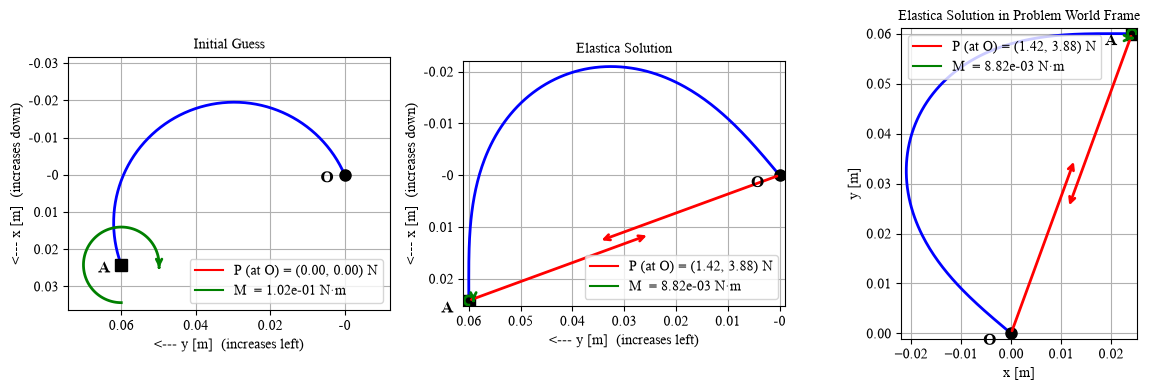

In [17]:
# Contact point and anchor point
O_eg = np.array([[0], [0]]).flatten()          # contact point (pinned)
A_eg = np.array([[0.0242], [0.06]]).flatten()  # example anchor point (fixed)

# Build mesh and initial guess array
s_mesh = np.linspace(0, L, N)
state_init_eg = np.zeros((6, N))
for i in range(N):
  state_init_eg[:, i] = guess(s_mesh[i], O_eg, A_eg)

# Extract initial states along nodes for plotting
snapshotInit = TailSnapshot(
    x_all = state_init_eg[0, :].copy(),
    y_all = state_init_eg[1, :].copy(),
    theta_all = state_init_eg[2, :].copy(),
    omega_all = np.zeros(N),
    M_all = state_init_eg[3, :].copy(),
    Px_all = state_init_eg[4, :].copy(),
    Py_all = state_init_eg[5, :].copy(),
    A = A_eg,
    O = O_eg,
    t_sim = 0
)

# Solve BVP
sol = solve_bvp(f, make_bc(O_eg, A_eg, 0), s_mesh, state_init_eg)

# Extract solved states along nodes for plotting
snapshotSol = TailSnapshot(
    x_all = sol.y[0, :].copy(),
    y_all = sol.y[1, :].copy(),
    theta_all = sol.y[2, :].copy(),
    omega_all = np.zeros(N),
    M_all = sol.y[3, :].copy(),
    Px_all = sol.y[4, :].copy(),
    Py_all = sol.y[5, :].copy(),
    A = A_eg,
    O = O_eg,
    t_sim = 0
)

# Plot initial guess and elastica solution for arbitrary example A
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
plot_solution(snapshotInit, "Initial Guess", fig, axs[0], timoshenko_axes=True)
plot_solution(snapshotSol, "Elastica Solution", fig, axs[1], timoshenko_axes=True)
plot_solution(snapshotSol, "Elastica Solution in Problem World Frame", fig, axs[2])
plt.tight_layout()
plt.show()

### Demonstrating the elastica solver for a nonzero target angle

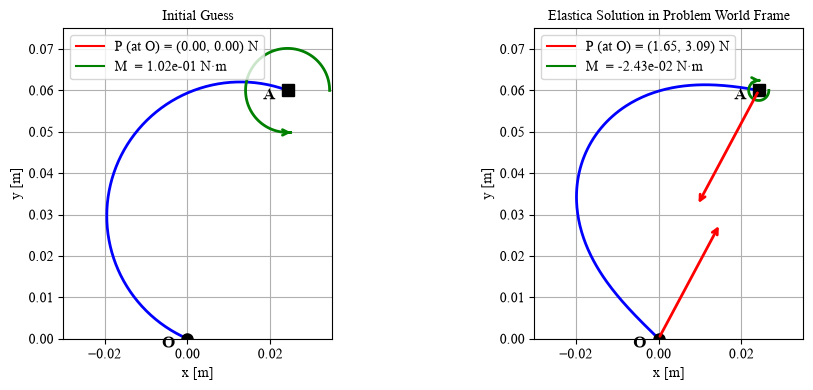

In [18]:
# Contact point and anchor point
O_eg = np.array([[0], [0]]).flatten()          # contact point (pinned)
A_eg = np.array([[0.0242], [0.06]]).flatten()  # example anchor point (fixed)

# Build mesh and initial guess array
s_mesh = np.linspace(0, L, N)
state_init_eg = np.zeros((6, N))
for i in range(N):
  state_init_eg[:, i] = guess(s_mesh[i], O_eg, A_eg)

# Extract initial states along nodes for plotting
snapshotInit = TailSnapshot(
    x_all = state_init_eg[0, :].copy(),
    y_all = state_init_eg[1, :].copy(),
    theta_all = state_init_eg[2, :].copy(),
    omega_all = np.zeros(N),
    M_all = state_init_eg[3, :].copy(),
    Px_all = state_init_eg[4, :].copy(),
    Py_all = state_init_eg[5, :].copy(),
    A = A_eg,
    O = O_eg,
    t_sim = 0
)

# Solve BVP
phi_eg = 2.96 # [rad]
theta_target = wrap(phi_eg - np.pi) # [rad]
sol = solve_bvp(f, make_bc(O_eg, A_eg, theta_target), s_mesh, state_init_eg)

# Extract solved states along nodes for plotting
snapshotSol = TailSnapshot(
    x_all = sol.y[0, :].copy(),
    y_all = sol.y[1, :].copy(),
    theta_all = sol.y[2, :].copy(),
    omega_all = np.zeros(N),
    M_all = sol.y[3, :].copy(),
    Px_all = sol.y[4, :].copy(),
    Py_all = sol.y[5, :].copy(),
    A = A_eg,
    O = O_eg,
    t_sim = 0
)

# Plot elastica solution for arbitrary anchor point and known robot orientation
fig, axs = plt.subplots(1, 2, figsize=(10, 4))
plot_solution(snapshotInit, "Initial Guess", fig, axs[0])
plot_solution(snapshotSol, "Elastica Solution in Problem World Frame", fig, axs[1])
axs[0].set_xlim([-0.03, 0.035])
axs[0].set_ylim([0, 0.075])
axs[1].set_xlim([-0.03, 0.035])
axs[1].set_ylim([0, 0.075])
plt.tight_layout()
plt.show()

### Calculate launch dynamics during tail extension

In [19]:
# Launch simulation loop
def run_launch_simulation_CR(damping_params, contact_pt, state_CR, dt, snapshot_dt,
                          tail_snapshots, robot_snapshots, debug_snapshots=None):
  # Launch simulation timestep
  t_sim = 0
  step = 0
  snapshot_interval = (int)(snapshot_dt / dt)
  t_max = 0.2 # check to not get stuck

  # Damping coefficients
  c_v = damping_params[0]
  c_om = damping_params[1]

  # Bookkeeping
  state_CG = np.zeros_like(state_CR)
  state_anchor = np.zeros_like(state_CR)

  while True:
    # Get state of center of rotation (CR)
    CR_pos = state_CR[0:2]      # 2x1 vector
    CR_linvel = state_CR[2:4]   # 2x1 vector
    phi = state_CR[4, 0]        # scalar: CCW is + rotation
    angvel = state_CR[5, 0]     # scalar

    # Determine anchor and CG locations in world frame
    CR_to_A = rot(phi) @ p_anchor
    anchor_world = CR_pos + CR_to_A
    CR_to_CG = rot(phi) @ p_CG
    CG_world = CR_pos + CR_to_CG

    # Log
    state_anchor[0:2] = anchor_world.copy()
    state_anchor[2:4] = CR_linvel + angvel * np.array([[-CR_to_A[1,0]], [CR_to_A[0,0]]])
    state_anchor[4, 0] = phi
    state_anchor[5, 0] = angvel
    state_CG[0:2] = CG_world.copy()
    state_CG[2:4] = CR_linvel + angvel * np.array([[-CR_to_CG[1,0]], [CR_to_CG[0,0]]])
    state_CG[4, 0] = phi
    state_CG[5, 0] = angvel

    CG_linvel = state_CG[2:4]

    # Build mesh and initial guess array
    s_mesh = np.linspace(0, L, N) # constrains tail to length L
    tail_state_init = np.zeros((6, N))
    for i in range(N):
      tail_state_init[:, i] = guess(s_mesh[i], contact_pt.flatten(), anchor_world.flatten())

    # Unwrap theta to avoid errors due to range
    # Effectively theta_target = wrap(phi - np.pi)
    tail_state_init[2, :] = np.unwrap(tail_state_init[2, :])
    theta_at_A_guess = tail_state_init[2, -1]
    desired_theta = phi - np.pi
    n = round((theta_at_A_guess - desired_theta) / (2*np.pi))
    theta_target = desired_theta + 2*np.pi*n

    # Grab initial snapshot
    snapshot_init = TailSnapshot(
      x_all = tail_state_init[0, :].copy(),
      y_all = tail_state_init[1, :].copy(),
      theta_all = tail_state_init[2, :].copy(),
      omega_all = np.zeros(N),
      M_all = tail_state_init[3, :].copy(),
      Px_all = tail_state_init[4, :].copy(),
      Py_all = tail_state_init[5, :].copy(),
      A = anchor_world,
      O = contact_pt,
      t_sim = 0
    )

    # SOLVE BVP
    bc = make_bc(contact_pt.flatten(), anchor_world.flatten(), theta_target)
    sol = solve_bvp(f, bc, s_mesh, tail_state_init)

    # Grab tail solution snapshot
    y_snap = sol.y.copy()
    tail_snapshot = TailSnapshot(
        x_all = y_snap[0],
        y_all = y_snap[1],
        theta_all = y_snap[2],
        omega_all = np.zeros(N),
        M_all = y_snap[3],
        Px_all = y_snap[4],
        Py_all = y_snap[5],
        A = anchor_world.copy(),
        O = contact_pt.copy(),
        t_sim = t_sim
    )

    # Determine forces and moment from tail on robot
    F_tail_on_body = np.array([[tail_snapshot.Px_all[0]], [tail_snapshot.Py_all[0]]])
    M_tail_on_body = -tail_snapshot.M_all[-1]
    F_weight = np.array([[0], [-m_bot*g]])

    # Linear motion of robot CG
    # Sum of forces on CG: F_tail_on_body - (0, mg) = ma
    CG_linaccel = (F_tail_on_body + F_weight - c_v*CG_linvel) / m_bot

    # Rotational motion around robot CG
    # Sum of moments around CG: M + (r x F) = I * alpha_rot
    CG_to_A = anchor_world - CG_world
    M_tailF = np.cross(np.append(CG_to_A.flatten(), 0),
                         np.append(F_tail_on_body.flatten(), 0))[-1]
    angaccel = (M_tail_on_body + M_tailF - c_om*angvel) / I_CM

    # Grab robot snapshot
    # Do before Euler step so initial state is at t = 0 and aligns with tail
    robot_snapshot = RobotSnapshot(
        state_CR = state_CR.copy(),
        state_anchor = state_anchor.copy(),
        state_CG = state_CG.copy(),
        F_anchor = F_tail_on_body,
        F_weight = F_weight,
        M_applied = M_tail_on_body,
        t_sim = t_sim
    )

    # Linear acceleration of CR via rigid body point relations
    CG_to_CR_3D = -np.append(CR_to_CG, 0).flatten()
    angvel_vec = np.array([[0], [0], [angvel]]).flatten()
    angaccel_vec = np.array([[0], [0], [angaccel]]).flatten()
    CR_linaccel = CG_linaccel + \
                  np.cross(angaccel_vec, CG_to_CR_3D)[0:-1].reshape(2,1) + \
                  np.cross(angvel_vec, np.cross(angvel_vec, CG_to_CR_3D))[0:-1].reshape(2,1)

    # Forward Euler step
    state_CR[0:2] = state_CR[0:2] + CR_linvel * dt    # CR_pos
    state_CR[2:4] = state_CR[2:4] + CR_linaccel * dt  # CR_linvel
    state_CR[4] = state_CR[4] + angvel * dt           # phi
    state_CR[5] = state_CR[5] + angaccel * dt         # angvel

    # Save select snapshots for plotting
    if step % snapshot_interval == 0:
      tail_snapshots.append(tail_snapshot)
      robot_snapshots.append(robot_snapshot)
      if debug_snapshots is not None:
        debug_snapshots.append(snapshot_init)

    t_sim = t_sim + dt
    step = step + 1

    # Break at launch
    if F_tail_on_body[1, 0] <= 0:
      print("Finished.")
      break

    # Infinite loop check
    if t_sim > t_max:
      print("Loop got stuck. Broke.")
      break

### Use example windup speed from Phase 1

In [20]:
# From phase 1
contact_pt_eg = np.array([[p_tail_eg[0,0]], [-r_wheel]]) # test value for low speeds (real world rocks)
state_CR_init = np.array([[0], [0], [0], [0], [wrap(phi_eg)], [0]])

# Simulation params
dt_launchsim = 1e-4
snapshot_dt = 1e-4

### Tune damping parameters on highest windup speed (example = 8.73 rad/s)

Finished.
Finished.
Loop got stuck. Broke.


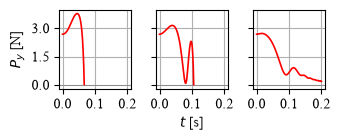

In [44]:
mag_vals   = np.array([0, 6.2, 12.4])
ratio_vals = np.array([0, 2.4, 4.8])

fig, axs = plt.subplots(1, len(mag_vals),
                         figsize=(3.5, 1.5),
                         sharex=True, sharey=True)

for i, (mag, ratio) in enumerate(zip(mag_vals, ratio_vals)):
    # Fresh snapshot lists for each combination
    ax = axs[i]
    tail_snapshots = []
    robot_snapshots = []
    debug_snapshots = []

    # Formulate damping coefficients from parameters
    c_v  = mag * 1e-1
    c_om = mag*ratio * 1e-4
    damping_coeffs = np.array([c_v, c_om])

    # Run launch simulation for each set of coefficients
    run_launch_simulation_CR(damping_coeffs, contact_pt_eg, state_CR_init.copy(), dt_launchsim, snapshot_dt,
                              tail_snapshots, robot_snapshots, debug_snapshots)

    # Plot vertical force on robot for coefficients
    t = np.array([s.t_sim for s in robot_snapshots])
    Fa_y = np.array([s.F_anchor[1, 0] for s in robot_snapshots])

    ax.plot(t, Fa_y, color='red', lw=1.2)
    ax.axhline(0, color='gray', lw=0.5)
    ax.grid(True)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(0.1))
    ax.yaxis.set_major_locator(mticker.MaxNLocator(nbins=3))

axs[1].set_xlabel('$t$ [s]')
axs[0].set_ylabel('$P_y$ [N]')

plt.tight_layout()
plt.savefig('damping_parameters.png', dpi=300, bbox_inches='tight')
plt.show()

### Simulate extension with tuned damping parameters for example windup speed

In [22]:
# Tuned damping parameters
mag = 6.2
ratio = 2.4
c_v  = mag * 1e-1
c_om = mag*ratio * 1e-4
damping_params = np.array([c_v, c_om])

# Logging
tail_snapshots = []
robot_snapshots = []
debug_snapshots = []

# Run simulation
run_launch_simulation_CR(damping_params, contact_pt_eg, state_CR_init.copy(), dt_launchsim, snapshot_dt,
                          tail_snapshots, robot_snapshots, debug_snapshots)

Finished.


### Plot tail and robot at initial contact and liftoff for example windup speed

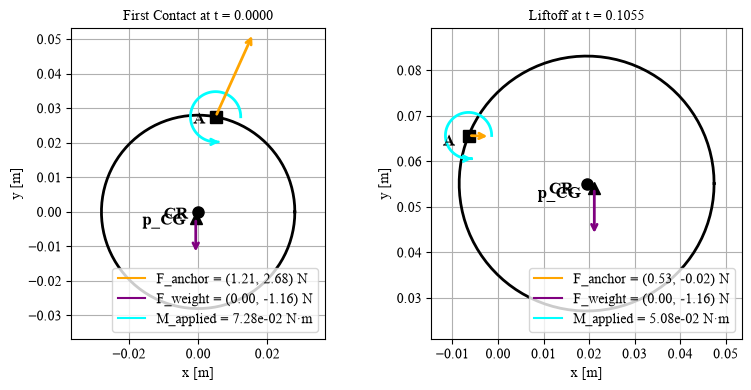

Number of snapshots: 1056


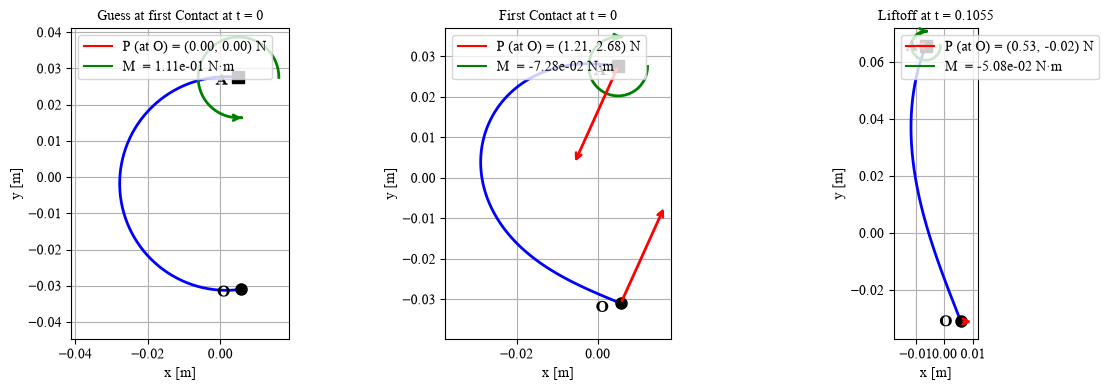

In [23]:
# Robot FBD at initial contact and liftoff
fig, axs = plt.subplots(1, 2, figsize = (8, 4))
plot_robot(robot_snapshots[0], f"First Contact at t = {robot_snapshots[0].t_sim:.4f}", fig, axs[0])
plot_robot(robot_snapshots[-1], f"Liftoff at t = {robot_snapshots[-1].t_sim:.4f}", fig, axs[1])
plt.tight_layout()
plt.show()

# Tail FBD at initial contact and liftoff
numsteps = len(tail_snapshots)
print(f"Number of snapshots: {numsteps}")

fig, axs = plt.subplots(1, 3, figsize = (12, 4))
plot_solution(debug_snapshots[0], f"Guess at first Contact at t = {debug_snapshots[0].t_sim}", fig, axs[0])
plot_solution(tail_snapshots[0], f"First Contact at t = {tail_snapshots[0].t_sim}", fig, axs[1])
plot_solution(tail_snapshots[-1], f"Liftoff at t = {tail_snapshots[-1].t_sim:.4f}", fig, axs[2])
plt.tight_layout()
plt.show()

### Plot combined system from initial contact to liftoff for example windup speed

Number of snapshots: 1056


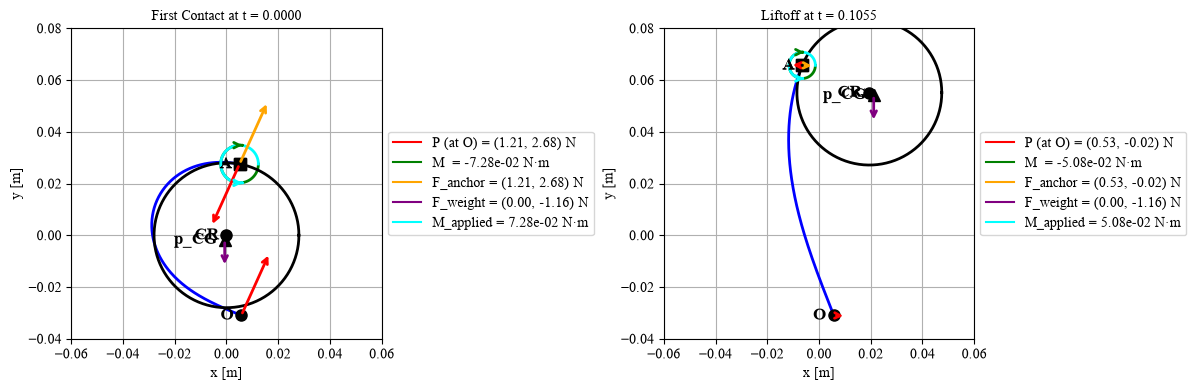

In [24]:
numsteps = len(tail_snapshots)
print(f"Number of snapshots: {numsteps}")

fig, axs = plt.subplots(1, 2, figsize = (12, 4))

# System at initial contact
plot_solution(tail_snapshots[0], f"First Contact at t = {tail_snapshots[0].t_sim}", fig, axs[0])
plot_robot(robot_snapshots[0], f"First Contact at t = {robot_snapshots[0].t_sim:.4f}", fig, axs[0])
axs[0].set_xlim([-0.06, 0.06])
axs[0].set_ylim([-0.04, 0.08])
axs[0].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

# System at liftoff
plot_solution(tail_snapshots[-1], f"Liftoff at t = {tail_snapshots[-1].t_sim:.4f}", fig, axs[1])
plot_robot(robot_snapshots[-1], f"Liftoff at t = {robot_snapshots[-1].t_sim:.4f}", fig, axs[1])
axs[1].set_xlim([-0.06, 0.06])
axs[1].set_ylim([-0.04, 0.08])
axs[1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)

plt.tight_layout()
plt.show()

### Visualize interactive evolution for example windup speed

In [25]:
from ipywidgets import interact, IntSlider, Layout
from IPython.display import display

numsteps = len(tail_snapshots)
print(f"Number of snapshots: {numsteps}")

def show_frame(i):
    fig, ax = plt.subplots(figsize=(7, 7))
    plot_solution(tail_snapshots[i],
                  f"t = {tail_snapshots[i].t_sim:.4f}", fig, ax)
    plot_robot(robot_snapshots[i],
               f"t = {robot_snapshots[i].t_sim:.4f}", fig, ax)
    ax.set_xlim([-0.06, 0.06])
    ax.set_ylim([-0.04, 0.09])
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    plt.tight_layout()
    plt.show()

interact(show_frame,
         i=IntSlider(min=0, max=numsteps-1, step=1, value=0,
                     description='snapshot', continuous_update=True,
                     layout=Layout(width='800px')))

Number of snapshots: 1056


interactive(children=(IntSlider(value=0, description='snapshot', layout=Layout(width='800px'), max=1055), Outp…

<function __main__.show_frame(i)>

### Stacked plots of robot history for example windup speed

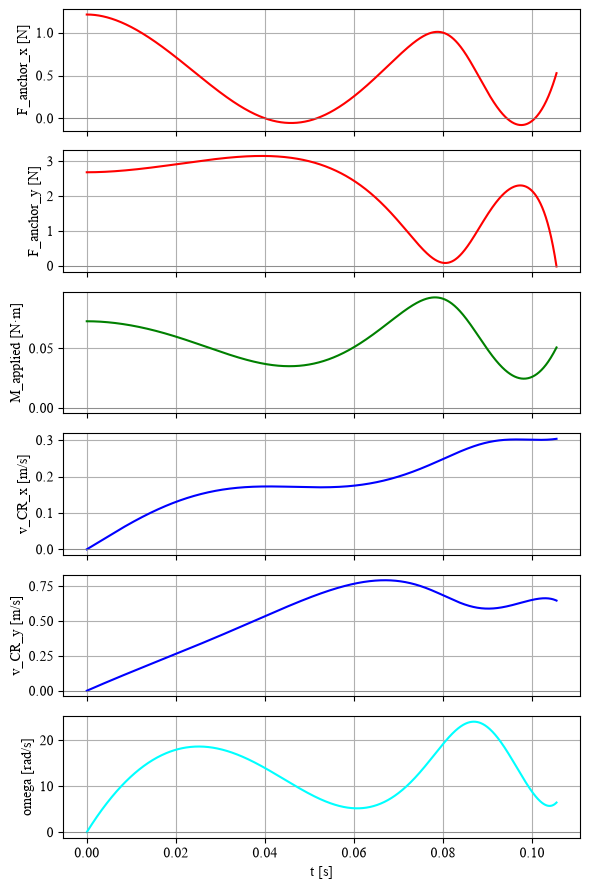

In [26]:
def plot_robot_history(snapshots):
    t       = np.array([s.t_sim                   for s in snapshots])
    Fa_x    = np.array([s.F_anchor[0, 0]          for s in snapshots])
    Fa_y    = np.array([s.F_anchor[1, 0]          for s in snapshots])
    M       = np.array([s.M_applied               for s in snapshots])
    v_x     = np.array([s.state_CR[2, 0]             for s in snapshots])
    v_y     = np.array([s.state_CR[3, 0]             for s in snapshots])
    omega   = np.array([s.state_CR[5, 0]             for s in snapshots])

    series = [
        (Fa_x,  'F_anchor_x [N]',       'red'),
        (Fa_y,  'F_anchor_y [N]',       'red'),
        (M,     'M_applied [N·m]',      'green'),
        (v_x,   'v_CR_x [m/s]',         'blue'),
        (v_y,   'v_CR_y [m/s]',         'blue'),
        (omega, 'omega [rad/s]',        'cyan'),
    ]

    fig, axes = plt.subplots(len(series), 1, figsize=(6, 1.5*len(series)),
                             sharex=True)
    for ax, (y, label, color) in zip(axes, series):
        ax.plot(t, y, color=color, lw=1.5)
        ax.axhline(0, color='gray', lw=0.5)
        ax.set_ylabel(label)
        ax.grid(True)
    axes[-1].set_xlabel('t [s]')
    plt.tight_layout()
    plt.show()

plot_robot_history(robot_snapshots)

### Simulate at every windup speed

In [27]:
dt_launchsim = 1e-4
snapshot_dt = 1e-4

vx_model = []
vy_model = []
v_model = []
theta_liftoff_model = []
phi_liftoff_model = []
omega_liftoff_model = []
liftoff_snapshots = []

phi_exp_vals = [dataframes[pct]['phi_contact'].mean() for pct in percentages]
contact_x_exp_vals = [dataframes[pct]['contact_x'].mean() for pct in percentages]

# Use experimental outputs from Phase 1 to simulate Phase 2 without carrying over Phase 1 model error
for phi_exp, contact_x_exp in zip(phi_exp_vals, contact_x_exp_vals):
    # Get contact point and initial state
    contact_pt2 = np.array([[contact_x_exp], [-r_wheel]])
    state_CR_init2 = np.array([[0], [0], [0], [0], [wrap(phi_exp)], [0]])

    # Run launch simulation
    tail_snapshots2 = []
    robot_snapshots2 = []
    debug_snapshots2 = []

    run_launch_simulation_CR(damping_params, contact_pt2, state_CR_init2, dt_launchsim, snapshot_dt,
                          tail_snapshots2, robot_snapshots2, debug_snapshots2)

    # Get liftoff state
    liftoff_snapshot2 = robot_snapshots2[-1]
    liftoff_snapshots.append(liftoff_snapshot2)
    state_liftoff2 = liftoff_snapshot2.state_CR
    t_lo = liftoff_snapshot2.t_sim
    x_lo, y_lo = state_liftoff2[0:2].flatten()
    vx_lo, vy_lo = state_liftoff2[2:4].flatten()
    theta_lo = state_liftoff2[4, 0]
    omega_lo = state_liftoff2[5, 0]

    v_liftoff = np.hypot(vx_lo, vy_lo)
    theta_liftoff = np.arctan2(vy_lo, vx_lo)

    # Log values
    vx_model.append(vx_lo)
    vy_model.append(vy_lo)
    v_model.append(v_liftoff)
    theta_liftoff_model.append(theta_liftoff)
    phi_liftoff_model.append(theta_lo + 2*np.pi)
    omega_liftoff_model.append(omega_lo)

Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.


### Phase 2 output plot: Model vs Results

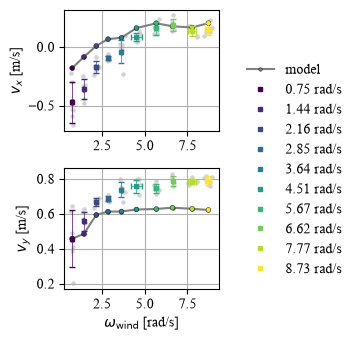

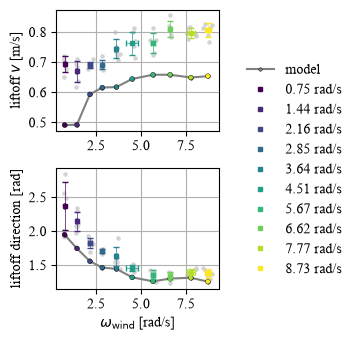

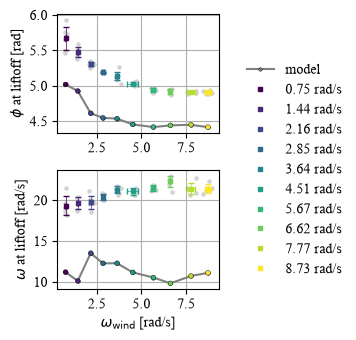

In [28]:
# Group variables in pairs: (vx, vy), (v, theta_liftoff), (phi_liftoff, omega_liftoff)
model_vars  = [vx_model, vy_model, v_model, theta_liftoff_model, phi_liftoff_model, omega_liftoff_model]
exp_cols    = ['vx_liftoff', 'vy_liftoff', 'v_liftoff', 'theta_liftoff', 'phi_liftoff', 'omega_liftoff']
ylabels     = [r'$v_x$ [m/s]', r'$v_y$ [m/s]', r'liftoff $v$ [m/s]', r'liftoff direction [rad]', r'$\phi$ at liftoff [rad]', r'$\omega$ at liftoff [rad/s]']
wrap_flags  = [False, False, False, False, True, False]   # wrap only phi at liftoff

# Sort by omega
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_wind_exp_vals_sorted  = np.array(omega_wind_exp_vals)[order]
pct_sorted     = np.array(commanded_pct)[order]

figs_axs = []

# Plot outputs vs windup speed for each pair
for fig_idx in range(3):
    fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
    figs_axs.append((fig, axs))

    pair_vars   = model_vars[2*fig_idx:2*fig_idx+2]
    pair_cols   = exp_cols[2*fig_idx:2*fig_idx+2]
    pair_labels = ylabels[2*fig_idx:2*fig_idx+2]
    pair_wraps  = wrap_flags[2*fig_idx:2*fig_idx+2]

    for ax, model_vals, exp_col, ylabel, wrap_ang in zip(axs, pair_vars, pair_cols, pair_labels, pair_wraps):
        model_sorted = np.array(model_vals)[order]

        # Plot model prediction + experimental results
        plot_panel(ax, omega_wind_exp_vals_sorted, model_sorted, exp_col, ylabel,
                   exp_colors, model_colors, wrap_ang=wrap_ang)

    axs[1].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

    # Single shared legend to the side
    handles, labels = legend_handles_labels(exp_colors)
    fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
              ncol=1, fontsize=10, frameon=False)

    plt.tight_layout()
    plt.show()

### Phase 2 model results summary

In [29]:
print("----------------------------\nModel results:\n----------------------------\n")

model_summary = pd.DataFrame({
    'pct':                  commanded_pct,
    'wind_omega_rad_s':     omega_wind_exp_vals,
    'contact_x':            contact_x_vals,
    'phi_contact':  phi_vals,          # phase-1 model contact phi
    'vx_liftoff':           vx_model,
    'vy_liftoff':           vy_model,
    'v_liftoff':            v_model,
    'theta_liftoff':         theta_liftoff_model,
}).set_index('pct')

# Match the experimental summary's column order for easy side-by-side reading
model_cols = ['wind_omega_rad_s', 'contact_x', 'phi_contact',
              'vx_liftoff', 'vy_liftoff', 'v_liftoff', 'theta_liftoff',
              'phi_liftoff', 'omega_liftoff', 'y_peak', 'x_end']
model_summary = model_summary[[c for c in model_cols if c in model_summary.columns]]
print(model_summary.to_string())
print("\n")

cols_to_drop = ['x_liftoff', 'y_liftoff', 'phi_liftoff', 'omega_liftoff', 'y_peak', 'x_end']
df_summary_cp = df_summary.drop(columns=cols_to_drop)
print("----------------------------\nExperimental results:\n----------------------------\n")
print(df_summary_cp.to_string())

----------------------------
Model results:
----------------------------

     wind_omega_rad_s  contact_x  phi_contact  vx_liftoff  vy_liftoff  v_liftoff  theta_liftoff
pct                                                                                            
10           0.750304   0.018369     3.382062   -0.181024    0.456843   0.491401       1.948066
20           1.436286   0.011810     3.152054   -0.086017    0.484652   0.492226       1.746449
30           2.160005   0.008667     3.043988    0.007738    0.593318   0.593369       1.557756
40           2.847189   0.007477     3.001006    0.065635    0.612240   0.615749       1.463999
50           3.636830   0.006796     2.977015    0.077527    0.612470   0.617358       1.444886
60           4.510609   0.006406     2.963470    0.159775    0.624153   0.644279       1.320190
70           5.671112   0.005989     2.953608    0.200543    0.626989   0.658280       1.261229
80           6.623388   0.005886     2.949483    0.174825    0

### Phase 2 RMSE

In [30]:
RMSE_P2_v_liftoff = np.sqrt(np.mean((v_model-df_summary['v_liftoff'])**2))
RMSE_P2_theta_liftoff = np.sqrt(np.mean((theta_liftoff_model-df_summary['theta_liftoff'])**2))

print(f"Phase 2 RMSE v_liftoff: {RMSE_P2_v_liftoff*1000:.0f} mm/s")
print(f"Phase 2 RMSE theta_liftoff: {np.degrees(RMSE_P2_theta_liftoff):.1f} degrees")

Phase 2 RMSE v_liftoff: 140 mm/s
Phase 2 RMSE theta_liftoff: 13.5 degrees


# Phase 3: Ballistic trajectory


### Plotting functions

In [31]:
# Plotting function for robot kinematic state
def plot_robot_state(snapshot, title, fig, ax, plot_tail=False):
    state_CR, state_anchor, state_CG, F_anchor, F_weight, M_applied, t_sim = astuple(snapshot)

    CR_pos = state_CR[0:2, 0]
    CR_linvel = state_CR[2:4, 0]
    CR_angvel = state_CR[5, 0]

    anchor_world = state_anchor[0:2, 0]
    anchor_linvel = state_anchor[2:4, 0]

    CG_world = state_CG[0:2, 0]
    CG_linvel = state_CG[2:4, 0]

    Fw_x, Fw_y = F_weight[0, 0], F_weight[1, 0]

    h_CR, v_CR = CR_pos[0], CR_pos[1]
    h_A,  v_A  = anchor_world[0], anchor_world[1]
    h_CG, v_CG = CG_world[0], CG_world[1]

    # Plot body circle around CR
    phi = np.linspace(0, 2*np.pi, 100)
    ax.plot(h_CR + r_body*np.cos(phi), v_CR + r_body*np.sin(phi), 'k-', lw=2)

    # Plot straight tail
    tail_end = np.array([0, 0])
    if plot_tail:
      tail_dir = rot(np.pi/2) @ (anchor_world - CR_pos)/np.linalg.norm(anchor_world - CR_pos)
      tail_end = anchor_world + tail_dir * 0.100
      ax.plot([anchor_world[0], tail_end[0]],
              [anchor_world[1], tail_end[1]], 'g-', lw=2)

    # Plot scaled gravity and linear velocity arrows
    def arrow(h, v, dh, dv, color):
      ax.annotate('', xy=(h + fs*dh, v + fs*dv), xytext=(h, v),
                      arrowprops=dict(arrowstyle='->', color=color, lw=2))
    arrow(h_CG, v_CG, Fw_x, Fw_y, 'dimgray')
    arrow(h_CR, v_CR, CR_linvel[0], CR_linvel[1], 'firebrick')
    arrow(h_A, v_A, anchor_linvel[0], anchor_linvel[1], 'deepskyblue')
    arrow(h_CG, v_CG, CG_linvel[0], CG_linvel[1], 'darkviolet')

    # Plot points CR, A, CG
    ax.plot(h_CR, v_CR, 'ko', ms=8)
    ax.plot(h_A,  v_A,  'ks', ms=8)
    ax.plot(h_CG, v_CG, 'k^', ms=8)

    off = 0.003
    for label, h, v in [('CR', h_CR, v_CR), ('A', h_A, v_A), ('CG', h_CG, v_CG)]:
        ax.annotate(label, xy=(h, v), xytext=(h-off, v-off),
                    fontsize=12, fontweight='bold', ha='right', va='bottom')

    # Plot angular-velocity arc arrow around CR
    r = 0.01
    sign = 1 if CR_angvel >= 0 else -1
    t = np.linspace(0, sign * 3*np.pi/2, 100)
    arc_h, arc_v = h_CR + r*np.cos(t), v_CR + r*np.sin(t)
    ax.plot(arc_h, arc_v, '-', color='cyan', lw=2)

    tip_dh, tip_dv = -np.sin(t[-1])*sign, np.cos(t[-1])*sign
    tip = 0.15 * r
    ax.annotate('', xy=(arc_h[-1] + tip*tip_dh, arc_v[-1] + tip*tip_dv),
                    xytext=(arc_h[-1], arc_v[-1]),
                    arrowprops=dict(arrowstyle='->', color='cyan', lw=2))

    # Ensure the tips of the arrows are in the plot, or they won't get plotted
    all_h = [h_CR - r_body - r, h_CR + r_body + r,
             h_CR + fs*CR_linvel[0], h_CG + fs*Fw_x, tail_end[0]]
    all_v = [v_CR - r_body - r, v_CR + r_body + r,
             v_CR + fs*CR_linvel[1], v_CG + fs*Fw_y, -r_wheel]
    margin = 0.2*r
    ax.set_xlim(min(all_h) - margin, max(all_h) + margin)
    ax.set_ylim(min(all_v) - margin, max(all_v) + margin)

    # Add labels
    ax.plot([], [], color='dimgray', label=f'F_weight = ({Fw_x:.2f}, {Fw_y:.2f}) N')
    ax.plot([], [], color='firebrick',   label=f'v_CR = ({CR_linvel[0]:.2f}, {CR_linvel[1]:.2f}) m/s')
    ax.plot([], [], color='deepskyblue',   label=f'v_A = ({anchor_linvel[0]:.2f}, {anchor_linvel[1]:.2f}) m/s')
    ax.plot([], [], color='darkviolet',   label=f'v_CG = ({CG_linvel[0]:.2f}, {CG_linvel[1]:.2f}) m/s')
    ax.plot([], [], color='cyan',   label=f'omega = {CR_angvel:.2f} rad/s')
    ax.set_aspect('equal')
    ax.grid(True)

    ax.set_xlabel('x [m]')
    ax.set_ylabel('y [m]')
    ax.legend(loc='lower right')

    if title:
        ax.set_title(title)

### Robot state at liftoff for example windup speed

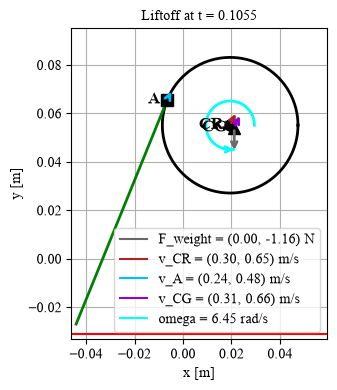

In [32]:
liftoff_snapshot = robot_snapshots[-1]

# Assumes tail instantaneously becomes flat at liftoff for visualization
fig, ax = plt.subplots(figsize=(4, 4))
plot_robot_state(liftoff_snapshot, f"Liftoff at t = {liftoff_snapshot.t_sim:.4f}", fig, ax, plot_tail=True)
plt.axhline(y = -r_wheel, color='r', linestyle='-')
plt.tight_layout()
plt.show()

### Calculations for state throughout ballistic trajectory

In [33]:
# State at CG
def state_at(state_init, t=0):
  x0, y0 = state_init[0:2].flatten()
  vx0, vy0 = state_init[2:4].flatten()
  phi0 = state_init[4, 0]
  omega0 = state_init[5, 0]

  # Use parabolic equations
  t_peak = vy0/g
  roots = np.roots([-0.5*g, vy0, y0])
  t_end = roots[roots.real >= 0].real.max() # latest non-negative landing time

  x = vx0*t + x0
  y = 0.5*-g*t**2 + vy0*t + y0
  vx = vx0
  vy = -g*t + vy0
  phi = phi0 + omega0*t #wrap(phi0 + omega0*t)

  state_CG = np.array([[x], [y], [vx], [vy], [phi], [omega0]])

  # Find CR from CG through rigid body relations
  CG_to_CR = -(rot(phi) @ p_CG)
  CR_pos = np.array([[x], [y]]) + CG_to_CR
  CR_vel = np.array([[vx], [vy]]) + omega0*np.array([[-CG_to_CR[1,0]],
                                                     [ CG_to_CR[0,0]]])
  state_CR = np.array([[CR_pos[0,0]], [CR_pos[1,0]],
                       [CR_vel[0,0]], [CR_vel[1,0]],
                       [phi], [omega0]])

  return state_CG, state_CR, t_peak, t_end

# Get CG state at liftoff
state_CG_lo = liftoff_snapshot.state_CG
_, _, t_peak, t_end = state_at(state_CG_lo)

# Determine maximum CR height y_peak across the full trajectory
ts = np.linspace(0, t_end, 2000)
y_CR = np.array([state_at(state_CG_lo, ti)[1][1, 0] for ti in ts])
y_peak = y_CR.max()

# Determine landing displacement of the CR at t_end
x_end = state_at(state_CG_lo, t_end)[1][0, 0]

### Visualize interactive trajectory for example windup speed

In [34]:
dt = 1e-3
numsteps = (int)(t_end / dt)
print(f"Number of snapshots: {numsteps}")

# Get state at t in snapshot format for plotting
def snapshot_at(liftoff_snapshot, t):
  state_CG, state_CR, t_peak, t_end = state_at(liftoff_snapshot.state_CG, t)

  CG_pos = state_CG[0:2, 0]
  CG_linvel = state_CG[2:4, 0]
  phi = state_CG[4, 0]
  angvel = state_CG[5, 0]

  # Get CR state and anchor state
  CR_pos = state_CR[0:2, 0]
  anchor_world = CR_pos + rot(phi) @ p_anchor.flatten()
  # v_anchor = v_CG + omega x (anchor - CG)
  anchor_linvel = [CG_linvel[0] - angvel * (anchor_world[1] - CG_pos[1]),
                   CG_linvel[1] + angvel * (anchor_world[0] - CG_pos[0])]

  state_anchor = np.array([[anchor_world[0]], [anchor_world[1]],
                           [anchor_linvel[0]], [anchor_linvel[1]],
                           [phi], [angvel]])

  # Return snapshot of state for plotting
  robot_snapshot = RobotSnapshot(
        state_CR = state_CR.copy(),
        state_anchor = state_anchor.copy(),
        state_CG = state_CG.copy(),
        F_anchor = 0,
        F_weight = liftoff_snapshot.F_weight,
        M_applied = 0,
        t_sim = t
    )
  return robot_snapshot

# Precompute snapshot list throughout trajectory
snapshots_traj = []
for i in range(numsteps):
  snapshots_traj.append(snapshot_at(liftoff_snapshot, dt * i))

def show_frame_traj(i):
    snap = snapshots_traj[i]
    fig, ax = plt.subplots(figsize=(10, 20))
    plot_robot_state(snap, f"t = {snap.t_sim:.3f}", fig, ax, plot_tail=True)
    plt.axhline(-r_wheel, color='r', linestyle='-')
    ax.set_xlim([-0.2, 0.2])
    ax.set_ylim([-r_wheel, 0.14])
    ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), borderaxespad=0)
    plt.tight_layout()
    plt.show()

interact(show_frame_traj,
         i=IntSlider(min=0, max=numsteps-1, step=1, value=0,
                     description='snapshot', continuous_update=True,
                     layout=Layout(width='800px')))


Number of snapshots: 191


interactive(children=(IntSlider(value=0, description='snapshot', layout=Layout(width='800px'), max=190), Outpu…

<function __main__.show_frame_traj(i)>

### Simulate at every windup speed

In [35]:
dt_launchsim = 1e-4
snapshot_dt = 1e-4

y_peaks_pred = []
x_ends_pred  = []
omegas_exp_means = []

# Use experimental outputs from Phase 2 to simulate Phase 3 without carrying over Phase 2 model error
for pct in percentages:
    row = df_summary.loc[pct]

    # Get CR state at liftoff
    CR_pos = np.array([[row['x_liftoff']],
                       [row['y_liftoff']]])
    CR_vel = np.array([[row['vx_liftoff']],
                       [row['vy_liftoff']]])
    phi = row['phi_liftoff']
    angvel = row['omega_liftoff']

    # Find CG liftoff state using rigid body relations
    CR_to_CG = rot(phi) @ p_CG
    CG_pos = CR_pos + CR_to_CG
    CG_vel = CR_vel + angvel * np.array([[-CR_to_CG[1, 0]],
                                         [ CR_to_CG[0, 0]]])
    state_CG_exp = np.array([
        [CG_pos[0, 0]],
        [CG_pos[1, 0]],
        [CG_vel[0, 0]],
        [CG_vel[1, 0]],
        [phi],
        [angvel],
    ])

    _, _, t_peak, t_end = state_at(state_CG_exp)

    # Determine max CR height y_peak
    ts = np.linspace(0, t_end, 2000)
    y_CR = np.array([state_at(state_CG_exp, ti)[1][1, 0] for ti in ts])
    y_peak = y_CR.max()

    # Determine landing displacement
    x_end = state_at(state_CG_exp, t_end)[1][0, 0]

    # Log
    y_peaks_pred.append(y_peak)
    x_ends_pred.append(x_end)
    omegas_exp_means.append(row['wind_omega_rad_s'])

### Phase 3 output plot: Model vs Results

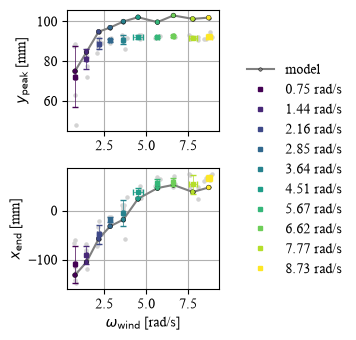

In [36]:
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))

# Sort by omega
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_wind_exp_vals_sorted = np.array(omega_wind_exp_vals)[order]

model_vars = [y_peaks_pred, x_ends_pred]
exp_cols   = ['y_peak', 'x_end']
ylabels    = [r'$y_\mathrm{peak}$ [mm]', r'$x_\mathrm{end}$ [mm]']

for ax, model_vals, exp_col, ylabel in zip(axs, model_vars, exp_cols, ylabels):
    model_sorted = np.array(model_vals)[order]

    # Plot predicted + experimental y_peak and x_end per windup speed (mm)
    plot_panel(ax, omega_wind_exp_vals_sorted, model_sorted, exp_col, ylabel,
               exp_colors, model_colors, scale=1000)

axs[1].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# Single shared legend beside subplots
handles, labels = legend_handles_labels(exp_colors)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           ncol=1, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

### Phase 3 RMSE

In [37]:
RMSE_P3_y_peak = np.sqrt(np.mean((y_peaks_pred-df_summary['y_peak'])**2))
RMSE_P3_x_end = np.sqrt(np.mean((x_ends_pred-df_summary['x_end'])**2))

print(f"Phase 3 RMSE y_peak: {RMSE_P3_y_peak*1000:.1f} mm")
print(f"Phase 3 RMSE x_end: {RMSE_P3_x_end*1000:.1f} mm")

Phase 3 RMSE y_peak: 7.9 mm
Phase 3 RMSE x_end: 14.4 mm


# Complete model pipeline

### Simulate using whole model pipeline for each windup speed

In [38]:
dt_launchsim = 1e-4
snapshot_dt = 1e-4

results = []

for pct, omega_rads in zip(percentages, omegas_exp_means):

    # --- Phase 1 ---
    windup_snaps = omega_to_contact_pt(omega_rads)
    p_tail_ct, phi_ct, CG_ct, anchor_ct, peel_ct, p_rod_offset_ct, t_ct = astuple(windup_snaps[-1])
    contact_x = p_tail_ct[0, 0]
    contact_pt = np.array([[p_tail_ct[0, 0]], [-r_wheel]])

    # Initial state at contact for CR
    state_init = np.array([[0], [0], [0], [0], [wrap(phi_ct)], [0]])

    # --- Phase 2 ---
    tail_snaps, robot_snaps, debug_snaps = [], [], []
    run_launch_simulation_CR(damping_params, contact_pt, state_init, dt_launchsim, snapshot_dt,
                          tail_snaps, robot_snaps, debug_snaps)
    liftoff_snapshot = robot_snaps[-1]      # state at liftoff
    state_CG_lo = liftoff_snapshot.state_CG
    state_lo = liftoff_snapshot.state_CR

    # --- Phase 3 ---
    _, _, t_peak, t_end = state_at(state_CG_lo)

    # Max CR height y_peak
    ts = np.linspace(0, t_end, 2000)
    y_CR = np.array([state_at(state_CG_lo, ti)[1][1, 0] for ti in ts])
    y_peak = y_CR.max()

    # Landing displacement at t_end (state_CR is the 2nd return)
    x_end = state_at(state_CG_lo, t_end)[1][0, 0]

    # Liftoff values
    x_lo, y_lo   = state_lo[0, 0], state_lo[1, 0]
    vx_lo, vy_lo = state_lo[2, 0], state_lo[3, 0]
    v_liftoff    = np.hypot(vx_lo, vy_lo)
    theta_liftoff = np.arctan2(vy_lo, vx_lo)
    theta_lo     = state_lo[4, 0]
    omega_lo     = state_lo[5, 0]
    t_lo         = liftoff_snapshot.t_sim

    # Save results
    results.append({
        'pct':           pct,
        'omega_rad_s':   omega_rads,
        'contact_x':     contact_x,
        'phi_contact': phi_ct % (2*np.pi),
        't_liftoff':     t_lo,
        'x_liftoff':     x_lo,
        'y_liftoff':     y_lo,
        'vx_liftoff':    vx_lo,
        'vy_liftoff':    vy_lo,
        'v_liftoff':     v_liftoff,
        'theta_liftoff':  theta_liftoff,
        't_peak':        t_peak,
        'y_peak':        y_peak,
        'theta_lo':      theta_lo,
        'omega_lo':      omega_lo,
        't_end':         t_end,
        'x_end':         x_end,
    })

# Save CSV
csv_path = 'launch_sweep.csv'
fieldnames = list(results[0].keys())
with open(csv_path, 'w', newline='') as csv_file:
    writer = csv.DictWriter(csv_file, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"\nSaved {csv_path}")

Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.
Finished.

Saved launch_sweep.csv


### Pipeline output plots: Model vs Results

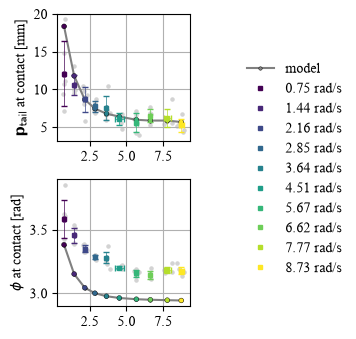

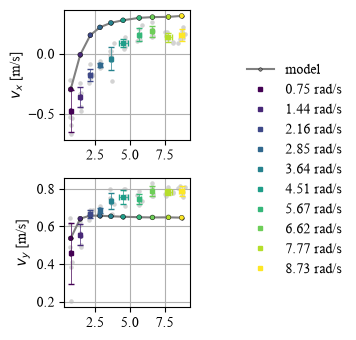

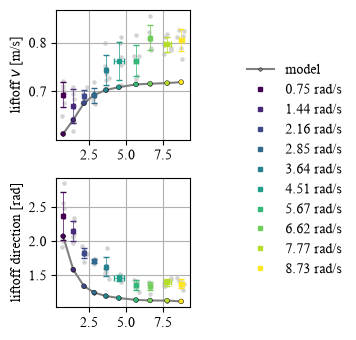

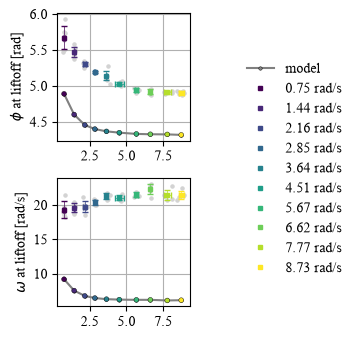

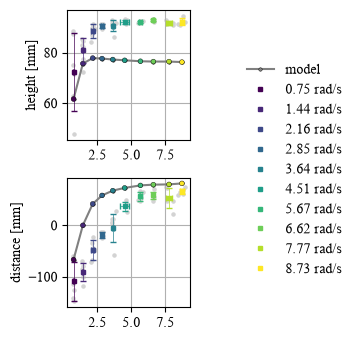

In [39]:
# Load results
model = pd.read_csv('launch_sweep.csv').sort_values('omega_rad_s').reset_index(drop=True)
model.index = df_summary.index
omega_wind_exp_vals_sorted = model['omega_rad_s'].to_numpy()
model_colors  = plt.cm.viridis(np.linspace(0, 1, len(model)))   # one color per sweep point
_, exp_colors, _ = sort_by_omega(omega_wind_exp_vals)

# Labels
handles, labels = legend_handles_labels(exp_colors)

# Plotting helper (reads model column from CSV; wrap uses [0,2pi) to match phases 1-3)
def overlay(ax, mcol, ecol, ylabel, wrap_ang=False, scale=1.0):
    w = wrap_02pi if wrap_ang else (lambda v: v)

    ax.plot(omega_wind_exp_vals_sorted, w(model[mcol])*scale, '-', color='gray', zorder=2,
            marker='o', markersize=2.5, markerfacecolor='gray',
            markeredgecolor='k', markeredgewidth=0.3, label='model')
    ax.scatter(omega_wind_exp_vals_sorted, w(model[mcol])*scale, color=model_colors,
               s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
    for pct, c in zip(percentages, exp_colors):
        df_pct = dataframes[pct]
        ax.scatter(df_pct['wind_omega_rad_s'], w(df_pct[ecol])*scale,
                   color='lightgray', s=5, zorder=1)
        om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
        v_m,  v_s  = w(df_pct[ecol]).mean()*scale, w(df_pct[ecol]).std()*scale
        ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                    fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                    zorder=4, label=f'{om_m:.2f} rad/s')
    ax.set_ylabel(ylabel)
    ax.grid(True)

# Phase 1: Contact x and contact orientation
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
overlay(axs[0], 'contact_x', 'contact_x', r'$\mathbf{p}_\mathrm{tail}$ at contact [mm]', scale=1000)
overlay(axs[1], 'phi_contact',  'phi_contact', r'$\phi$ at contact [rad]', wrap_ang=True)
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
            ncol=1, fontsize=10, frameon=False)
plt.show()

# Phase 2: Liftoff x and y velocities
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
axs = axs.flatten()
overlay(axs[0], 'vx_liftoff',   'vx_liftoff',   r'$v_x$ [m/s]')
overlay(axs[1], 'vy_liftoff',   'vy_liftoff',   r'$v_y$ [m/s]')
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
            ncol=1, fontsize=10, frameon=False)
plt.show()

# Phase 2: Liftoff velocity and direction
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
axs = axs.flatten()
overlay(axs[0], 'v_liftoff',    'v_liftoff',    r'liftoff $v$ [m/s]')
overlay(axs[1], 'theta_liftoff', 'theta_liftoff', r'liftoff direction [rad]')
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
            ncol=1, fontsize=10, frameon=False)
plt.show()

# Phase 2: Liftoff omega and liftoff orientation
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
axs = axs.flatten()
overlay(axs[0], 'theta_lo',   'phi_liftoff',  r'$\phi$ at liftoff [rad]', wrap_ang=True)
overlay(axs[1], 'omega_lo',   'omega_liftoff',   r'$\omega$ at liftoff [rad/s]')
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
            ncol=1, fontsize=10, frameon=False)
plt.show()

# Phase 3 Trajectory: Peak height and landing distance
fig, axs = plt.subplots(2, 1, figsize=(2.39, 3.5))
overlay(axs[0], 'y_peak', 'y_peak', r'height [mm]',   scale=1000)
overlay(axs[1], 'x_end',  'x_end',  r'distance [mm]', scale=1000)
plt.tight_layout(rect=[0, 0, 0.88, 1])
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
            ncol=1, fontsize=10, frameon=False)
plt.show()

### Pipeline RMSE

In [40]:
RMSE_theta_liftoff = np.sqrt(np.mean((model['theta_liftoff']-df_summary['theta_liftoff'])**2))
RMSE_y_peak = np.sqrt(np.mean((model['y_peak']-df_summary['y_peak'])**2))
RMSE_x_end = np.sqrt(np.mean((model['x_end']-df_summary['x_end'])**2))

print(f"Pipeline RMSE theta_liftoff: {np.degrees(RMSE_theta_liftoff):.1f} degrees")
print(f"Pipeline RMSE y_peak: {RMSE_y_peak*1000:.1f} mm")
print(f"Pipeline RMSE x_end: {RMSE_x_end*1000:.1f} mm")

Pipeline RMSE theta_liftoff: 21.1 degrees
Pipeline RMSE y_peak: 13.5 mm
Pipeline RMSE x_end: 56.9 mm


### Phase 1, Phase 2, and Phase 3 per-phase output plots: Model vs Results

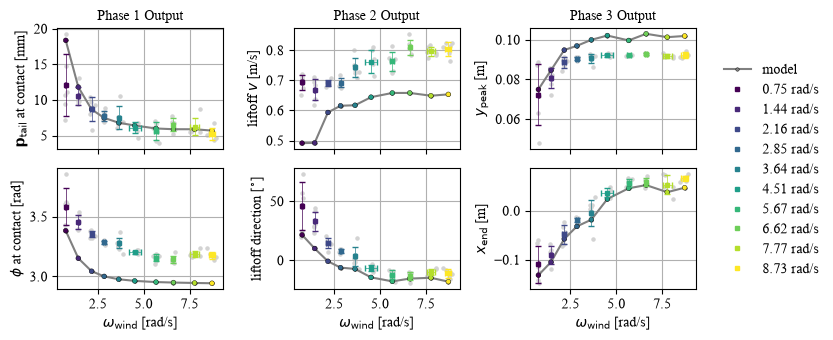

In [43]:
fig, axs = plt.subplots(2, 3, figsize=(7.16, 3.5), sharex=True)

# Single shared sort key + colors for all three phases
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_sorted = np.array(omega_wind_exp_vals)[order]

# ---------------- Column 1: Phase 1 (contact_x, phi) ----------------
commanded_pct = df_summary.index
contact_x_vals    = [cs.p_tail[0,0] for cs in contact_snapshots]
phi_vals  = [cs.phi + 2*np.pi if cs.phi < 0 else cs.phi for cs in contact_snapshots]

contact_x_vals_sorted = np.array(contact_x_vals)[order]
phi_vals_sorted       = np.array(phi_vals)[order]

# contact_x in mm (scale=1000); phi wrapped to [0,2pi) to match other phases
plot_panel(axs[0, 0], omega_sorted, contact_x_vals_sorted, 'contact_x',
           r'$\mathbf{p}_\mathrm{tail}$ at contact [mm]',
           exp_colors, model_colors, scale=1000)
plot_panel(axs[1, 0], omega_sorted, phi_vals_sorted, 'phi_contact',
           r'$\phi$ at contact [rad]',
           exp_colors, model_colors, wrap_ang=True)

axs[0, 0].set_title('Phase 1 Output')

# ---------------- Column 2: Phase 2 (v, theta_liftoff) ----------------
v_model_sorted = np.array(v_model)[order]
plot_panel(axs[0, 1], omega_sorted, v_model_sorted, 'v_liftoff',
           r'liftoff $v$ [m/s]', exp_colors, model_colors)

ax = axs[1, 1]
model_dir = np.degrees(np.array(theta_liftoff_model) - np.pi/2)[order] # from vertical, deg
ax.plot(omega_sorted, model_dir, '-', color='gray', zorder=2,
         marker='o', markersize=2.5, markerfacecolor='gray',
         markeredgecolor='k', markeredgewidth=0.3, label='model')
ax.scatter(omega_sorted, model_dir, color=model_colors,
           s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
for pct, c in zip(percentages, exp_colors):
    df_pct = dataframes[pct]
    vals = np.degrees(df_pct['theta_liftoff'] - np.pi/2) # display from vertical, in degrees
    ax.scatter(df_pct['wind_omega_rad_s'], vals, color='lightgray', s=5, zorder=1)
    om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
    v_m,  v_s  = vals.mean(), vals.std()
    ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                zorder=4, label=f'{om_m:.2f} rad/s')
ax.set_ylabel(r'liftoff direction [$^{\circ}$]')
ax.grid(True)

axs[0, 1].set_title('Phase 2 Output')

# ---------------- Column 3: Phase 3 (height, distance) ----------------
dt_launchsim = 1e-4
snapshot_dt  = 1e-4

y_peaks_pred = []
x_ends_pred  = []

for pct in percentages:
    row_data = df_summary.loc[pct]

    CR_pos = np.array([[row_data['x_liftoff']], [row_data['y_liftoff']]])
    CR_vel = np.array([[row_data['vx_liftoff']], [row_data['vy_liftoff']]])
    phi = row_data['phi_liftoff']
    angvel      = row_data['omega_liftoff']

    CR_to_CG = rot(phi) @ p_CG
    CG_pos = CR_pos + CR_to_CG
    CG_vel = CR_vel + angvel * np.array([[-CR_to_CG[1, 0]], [ CR_to_CG[0, 0]]])
    state_CG_exp = np.array([
        [CG_pos[0, 0]], [CG_pos[1, 0]],
        [CG_vel[0, 0]], [CG_vel[1, 0]],
        [phi], [angvel],
    ])

    _, _, t_peak, t_end = state_at(state_CG_exp)

    ts = np.linspace(0, t_end, 2000)
    y_CR = np.array([state_at(state_CG_exp, ti)[1][1, 0] for ti in ts])
    y_peak = y_CR.max()
    x_end  = state_at(state_CG_exp, t_end)[1][0, 0]

    y_peaks_pred.append(y_peak)
    x_ends_pred.append(x_end)

model_vars_p3 = [y_peaks_pred, x_ends_pred]
exp_cols_p3   = ['y_peak', 'x_end']
ylabels_p3    = [r'$y_\mathrm{peak}$ [m]', r'$x_\mathrm{end}$ [m]']

for row, (model_vals, exp_col, ylabel) in enumerate(zip(model_vars_p3, exp_cols_p3, ylabels_p3)):
    model_sorted = np.array(model_vals)[order]
    plot_panel(axs[row, 2], omega_sorted, model_sorted, exp_col, ylabel,
               exp_colors, model_colors)

axs[0, 2].set_title('Phase 3 Output')

# ---------------- Shared x labels (bottom row only) ----------------
for col in range(3):
    axs[1, col].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# ---------------- Single shared legend ----------------
handles, labels = legend_handles_labels(exp_colors)
fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5),
           ncol=1, fontsize=10, frameon=False)

plt.tight_layout()
plt.show()

### Per-phase plots combined with pipeline plots

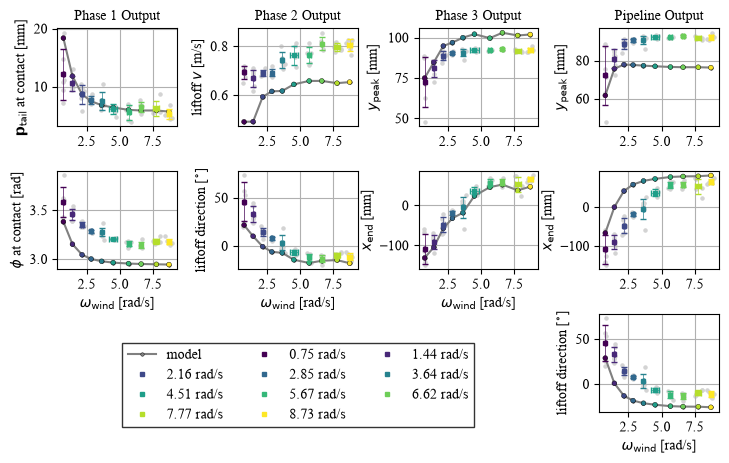

In [42]:
fig, axs = plt.subplots(3, 4, figsize=(7.16, 4.5))

# Single shared sort key + colors for all columns
order, exp_colors, model_colors = sort_by_omega(omega_wind_exp_vals)
omega_sorted = np.array(omega_wind_exp_vals)[order]

# ---------------- Column 0: Phase 1 (contact_x, phi) ----------------
commanded_pct = df_summary.index
contact_x_vals    = [cs.p_tail[0,0] for cs in contact_snapshots]
phi_vals  = [cs.phi + 2*np.pi if cs.phi < 0 else cs.phi for cs in contact_snapshots]

contact_x_vals_sorted = np.array(contact_x_vals)[order]
phi_vals_sorted       = np.array(phi_vals)[order]

# contact_x in mm (scale=1000); phi wrapped to [0,2pi) to match other phases
plot_panel(axs[0, 0], omega_sorted, contact_x_vals_sorted, 'contact_x',
           r'$\mathbf{p}_\mathrm{tail}$ at contact [mm]',
           exp_colors, model_colors, scale=1000)
plot_panel(axs[1, 0], omega_sorted, phi_vals_sorted, 'phi_contact',
           r'$\phi$ at contact [rad]',
           exp_colors, model_colors, wrap_ang=True)

axs[0, 0].set_title('Phase 1 Output')
axs[1, 0].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# ---------------- Column 1: Phase 2 (v, theta_liftoff) ----------------
# liftoff v: clean mapping -> plot_panel
v_model_sorted = np.array(v_model)[order]
plot_panel(axs[0, 1], omega_sorted, v_model_sorted, 'v_liftoff',
           r'liftoff $v$ [m/s]', exp_colors, model_colors)

# liftoff direction: from vertical, in degrees. Per-value transform on experiment
# keeps this panel inline.
ax = axs[1, 1]
model_dir = np.degrees(np.array(theta_liftoff_model) - np.pi/2)[order]
ax.plot(omega_sorted, model_dir, '-', color='gray', zorder=2,
         marker='o', markersize=2.5, markerfacecolor='gray',
         markeredgecolor='k', markeredgewidth=0.3, label='model')
ax.scatter(omega_sorted, model_dir, color=model_colors,
           s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
for pct, c in zip(percentages, exp_colors):
    df_pct = dataframes[pct]
    vals = np.degrees(df_pct['theta_liftoff'] - np.pi/2)
    ax.scatter(df_pct['wind_omega_rad_s'], vals, color='lightgray', s=5, zorder=1)
    om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
    v_m,  v_s  = vals.mean(), vals.std()
    ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                zorder=4, label=f'{om_m:.2f} rad/s')
ax.set_ylabel(r'liftoff direction [$^{\circ}$]')
ax.grid(True)

axs[0, 1].set_title('Phase 2 Output')
axs[1, 1].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# ---------------- Column 2: Phase 3 (height, distance) — in mm ----------------
y_peaks_pred     = []
x_ends_pred      = []

for pct in percentages:
    row_data = df_summary.loc[pct]
    CR_pos = np.array([[row_data['x_liftoff']], [row_data['y_liftoff']]])
    CR_vel = np.array([[row_data['vx_liftoff']], [row_data['vy_liftoff']]])
    phi = row_data['phi_liftoff']
    angvel      = row_data['omega_liftoff']
    CR_to_CG = rot(phi) @ p_CG
    CG_pos = CR_pos + CR_to_CG
    CG_vel = CR_vel + angvel * np.array([[-CR_to_CG[1, 0]], [CR_to_CG[0, 0]]])
    state_CG_exp = np.array([
        [CG_pos[0, 0]], [CG_pos[1, 0]],
        [CG_vel[0, 0]], [CG_vel[1, 0]],
        [phi], [angvel],
    ])
    _, _, t_peak, t_end = state_at(state_CG_exp)
    ts   = np.linspace(0, t_end, 2000)
    y_CR = np.array([state_at(state_CG_exp, ti)[1][1, 0] for ti in ts])
    y_peaks_pred.append(y_CR.max())
    x_ends_pred.append(state_at(state_CG_exp, t_end)[1][0, 0])

model_vars_p3 = [y_peaks_pred, x_ends_pred]
exp_cols_p3   = ['y_peak', 'x_end']
ylabels_p3    = [r'$y_\mathrm{peak}$ [mm]', r'$x_\mathrm{end}$ [mm]']

for row, (model_vals, exp_col, ylabel) in enumerate(zip(model_vars_p3, exp_cols_p3, ylabels_p3)):
    model_sorted = np.array(model_vals)[order]
    plot_panel(axs[row, 2], omega_sorted, model_sorted, exp_col, ylabel,
               exp_colors, model_colors, scale=1000)  # m -> mm

axs[0, 2].set_title('Phase 3 Output')
axs[1, 2].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# ---------------- Column 3: Pipeline output — in mm ----------------
plot_panel(axs[0, 3], omega_sorted, model['y_peak'].to_numpy(), 'y_peak',
           r'$y_\mathrm{peak}$ [mm]', exp_colors, model_colors, scale=1000)
plot_panel(axs[1, 3], omega_sorted, model['x_end'].to_numpy(), 'x_end',
           r'$x_\mathrm{end}$ [mm]', exp_colors, model_colors, scale=1000)

ax = axs[2, 3]
model_dir_pipe = np.degrees(model['theta_liftoff'].to_numpy() - np.pi/2)
ax.plot(omega_sorted, model_dir_pipe, '-', color='gray', zorder=2,
         marker='o', markersize=2.5, markerfacecolor='gray',
         markeredgecolor='k', markeredgewidth=0.3, label='model')
ax.scatter(omega_sorted, model_dir_pipe, color=model_colors,
           s=12, marker='o', edgecolor='k', linewidth=0.3, zorder=3)
for pct, c in zip(percentages, exp_colors):
    df_pct = dataframes[pct]
    vals = np.degrees(df_pct['theta_liftoff'] - np.pi/2)  # match phase 2 convention
    ax.scatter(df_pct['wind_omega_rad_s'], vals, color='lightgray', s=5, zorder=1)
    om_m, om_s = df_pct['wind_omega_rad_s'].mean(), df_pct['wind_omega_rad_s'].std()
    v_m,  v_s  = vals.mean(), vals.std()
    ax.errorbar(om_m, v_m, xerr=om_s, yerr=v_s,
                fmt='s', color=c, ms=2.5, capsize=2, elinewidth=0.5,
                zorder=4, label=f'{om_m:.2f} rad/s')
ax.set_ylabel(r'liftoff direction [$^{\circ}$]')
ax.grid(True)

axs[0, 3].set_title('Pipeline Output')
axs[2, 3].set_xlabel(r'$\omega_\mathrm{wind}$ [rad/s]')

# ---------------- Bottom row: turn off first three cells ----------------
axs[2, 0].axis('off')
axs[2, 1].axis('off')
axs[2, 2].axis('off')

# Build legend handles
handles, labels = legend_handles_labels(exp_colors)

# Rearrange handles/labels for row-major fill (left-to-right, then next row)
n_items = len(handles)
n_rows  = 4
n_cols  = math.ceil(n_items / n_rows)   # 3 rows
storage_order = []
for i in range(n_items):
    row_i = i % n_rows
    col_i = i // n_rows
    desired_idx = row_i * n_cols + col_i
    if desired_idx < n_items:
        storage_order.append(desired_idx)
handles_ro = [handles[i] for i in storage_order]
labels_ro  = [labels[i]  for i in storage_order]

plt.tight_layout(pad=0.25, h_pad=0.25, w_pad=0.25)

bbox_left  = axs[2, 0].get_position()
bbox_right = axs[2, 2].get_position()
legend_ax  = fig.add_axes([
    bbox_left.x0,
    bbox_left.y0 - 0.05,
    bbox_right.x1 - bbox_left.x0,
    bbox_left.height
])
legend_ax.axis('off')
legend_ax.legend(handles_ro, labels_ro, loc='center', fontsize=10,
                 frameon=True, ncol=n_cols,
                 edgecolor='black', fancybox=False)

plt.savefig('phases_pipeline_summary.png', dpi=300, bbox_inches='tight')
plt.show()

#